# Compare Two Methods on MMLU

This notebook compares **the same experiments** for two methods:

1. **Baseline:** regular Qwen + confidence threshold  
   - Model only predicts `A/B/C/D`.
   - Abstention is created by thresholding the maximum answer confidence.

2. **DK / Smart Chimera:** Qwen trained with `A/B/C/D/E`, where `E = DK`  
   - Model can directly predict `E`.
   - Main decision rule is **argmax-only**: if `E` has the highest probability, the model refuses.

The notebook uses the same train/validation/test split, same MMLU samples, and produces comparable metrics/graphs.

In [48]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [49]:
# Optional installs. Run this cell in Colab if needed.
!pip install -q -U "torchao>=0.16.0" transformers datasets peft accelerate scikit-learn matplotlib pandas tqdm

In [50]:
import os
import random
import copy
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(100)

Using device: cuda


In [51]:
@dataclass
class Config:
    model_name: str = "Qwen/Qwen3-0.6B"
    max_length: int = 512
    batch_size: int = 32
    num_workers: int = 0
    lr: float = 2e-5
    chimera_lr: float = 5e-6
    num_epochs_baseline: int = 1
    num_epochs_dk_regular: int = 1
    num_epochs_dk_truncate: int = 1
    num_epochs_dk_chimera: int = 1
    train_sample_limit: int = 100000
    val_sample_limit: int = 5000
    test_sample_limit: int = 20000
    m_steps: int = 3
    chimera_ratio: float = 1
    dk_soft_target: float = 0.5
    seed: int = 100
    cache_dir: str = "comparison_cached_datasets"
    checkpoint_dir: str = "comparison_checkpoints"
    force_rebuild_cache: bool = False
    to_train: bool = True

config = Config()
os.makedirs(config.cache_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)
config

Config(model_name='Qwen/Qwen3-0.6B', max_length=512, batch_size=32, num_workers=0, lr=2e-05, chimera_lr=5e-06, num_epochs_baseline=1, num_epochs_dk_regular=1, num_epochs_dk_truncate=1, num_epochs_dk_chimera=1, train_sample_limit=100000, val_sample_limit=5000, test_sample_limit=20000, m_steps=3, chimera_ratio=1, dk_soft_target=0.5, seed=100, cache_dir='comparison_cached_datasets', checkpoint_dir='comparison_checkpoints', force_rebuild_cache=False, to_train=True)

## Prompt formats

The baseline prompt has only `A/B/C/D`.  
The DK prompt has `A/B/C/D/E`, where `E` means *I don't know*.

In [52]:
def build_prompt_baseline(question, answers: list[str]):
    letters = ["A", "B", "C", "D"]
    prompted_answers = "\n".join(f"{letters[i]}. {answer}" for i, answer in enumerate(answers[:4]))
    return (
        f"Question:\n{question}\n\n"
        f"Choices:\n{prompted_answers}\n\n"
        f"Return only one letter: A, B, C, or D.\n"
        f"Answer:"
    )


def build_prompt_dk(question, answers: list[str]):
    letters = ["A", "B", "C", "D"]
    prompted_answers = "\n".join(f"{letters[i]}. {answer}" for i, answer in enumerate(answers[:4]))
    return (
        f"Question:\n{question}\n\n"
        f"Choices:\n{prompted_answers}\n"
        f"E. I don't know\n\n"
        f"Return only one letter: A, B, C, D, or E.\n"
        f"Answer:"
    )

## Load MMLU once and create shared splits

Both methods use the exact same selected rows. Validation is used only for choosing operating points / thresholds. Test is used only for final reporting.

In [53]:
mmlu = load_dataset("cais/mmlu", "all")
print(mmlu)

train_split = "auxiliary_train" if "auxiliary_train" in mmlu else "dev"
val_split = "validation" if "validation" in mmlu else train_split
test_split = "test"

train_source = mmlu[train_split].select(range(min(config.train_sample_limit, len(mmlu[train_split]))))

if val_split == train_split:
    val_start = min(config.train_sample_limit, len(mmlu[train_split]))
    val_end = min(val_start + config.val_sample_limit, len(mmlu[train_split]))
    val_source = mmlu[train_split].select(range(val_start, val_end))
else:
    val_source = mmlu[val_split].select(range(min(config.val_sample_limit, len(mmlu[val_split]))))

test_source = mmlu[test_split].select(range(min(config.test_sample_limit, len(mmlu[test_split]))))

small_mmlu = DatasetDict({
    "train": train_source,
    "validation": val_source,
    "test": test_source,
})

print("train:", len(small_mmlu["train"]))
print("validation:", len(small_mmlu["validation"]))
print("test:", len(small_mmlu["test"]))

DatasetDict({
    test: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 14042
    })
    validation: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 1531
    })
    dev: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 285
    })
    auxiliary_train: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 99842
    })
})
train: 99842
validation: 1531
test: 14042


In [54]:
tokenizer = AutoTokenizer.from_pretrained(config.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("pad_token:", tokenizer.pad_token)

pad_token: <|endoftext|>


## Dataset classes

`RegularABCDDataset` is used for the baseline and for normal DK evaluation.  
`DKTrainingDataset` supports:

- `regular`: clean full questions with one-hot answer labels.
- `truncate`: partial questions with soft labels moving from DK toward the true answer.
- `smart_chimera`: normal-looking questions where the correct answer is removed or choices are swapped, trained toward DK.

In [55]:
class RegularABCDDataset(Dataset):
    def __init__(self, ds, split, tokenizer, max_length=512):
        rows = list(ds[split])
        prompts, answers, subjects = [], [], []

        for row in rows:
            prompts.append(build_prompt_baseline(row["question"], row["choices"]))
            answers.append(int(row["answer"]))
            subjects.append(row.get("subject", "unknown"))

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )

        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.answers = torch.tensor(answers, dtype=torch.long)
        self.subjects = subjects

    def __len__(self):
        return len(self.answers)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "answer": self.answers[idx],
            "subject": self.subjects[idx],
        }


class DKRegularDataset(Dataset):
    '''Clean MMLU examples with DK-style prompt, but true labels remain A/B/C/D.'''
    def __init__(self, ds, split, tokenizer, max_length=512):
        rows = list(ds[split])
        prompts, answers, subjects = [], [], []

        for row in rows:
            prompts.append(build_prompt_dk(row["question"], row["choices"]))
            answers.append(int(row["answer"]))
            subjects.append(row.get("subject", "unknown"))

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )

        self.samples = []
        for i in range(len(prompts)):
            y = torch.zeros(5, dtype=torch.float32)
            y[answers[i]] = 1.0
            self.samples.append({
                "input_ids": enc["input_ids"][i],
                "attention_mask": enc["attention_mask"][i],
                "answer": torch.tensor(answers[i], dtype=torch.long),
                "soft_labels": y,
                "subject": subjects[i],
                "kind": "clean",
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [56]:
def cutted_question(question, m_steps):
    '''Simple progressive reveal by word chunks. Last step is the full question.'''
    words = str(question).split()
    if len(words) == 0:
        return [question] * m_steps, [1.0] * m_steps

    outputs, ratios = [], []
    for step in range(1, m_steps + 1):
        keep = max(1, int(np.ceil(len(words) * step / m_steps)))
        outputs.append(" ".join(words[:keep]))
        ratios.append(step / m_steps)
    ratios[-1] = 1.0
    outputs[-1] = question
    return outputs, ratios


def soft_one_hot(label_idx, num_classes=5, confidence=1.0):
    y = torch.full((num_classes,), (1.0 - confidence) / (num_classes - 1), dtype=torch.float32)
    y[label_idx] = confidence
    return y


def make_soft_dk_label(dk_prob=0.85):
    return soft_one_hot(label_idx=4, num_classes=5, confidence=dk_prob)


def build_subject_index_from_rows(rows):
    subject_to_indices = defaultdict(list)
    for i, row in enumerate(rows):
        subject_to_indices[row.get("subject", "unknown")].append(i)
    return subject_to_indices


def get_candidate_indices_same_subject(row, all_rows, subject_to_indices):
    subject = row.get("subject", "unknown")
    candidates = subject_to_indices.get(subject, [])
    if len(candidates) <= 1:
        candidates = list(range(len(all_rows)))
    return candidates


def make_remove_correct_answer_chimera(row, all_rows, subject_to_indices, dk_prob=0.85, max_tries=50):
    answer_idx = int(row["answer"])
    new_choices = list(row["choices"][:4])
    candidate_indices = get_candidate_indices_same_subject(row, all_rows, subject_to_indices)

    replacement = None
    for _ in range(max_tries):
        other = all_rows[random.choice(candidate_indices)]
        if other["question"] == row["question"]:
            continue

        other_answer = int(other["answer"])
        wrong_pool = [
            c for k, c in enumerate(other["choices"][:4])
            if k != other_answer and c not in new_choices
        ]
        if wrong_pool:
            replacement = random.choice(wrong_pool)
            break

    if replacement is None:
        return None

    new_choices[answer_idx] = replacement
    return {
        "prompt": build_prompt_dk(row["question"], new_choices),
        "answer": 4,
        "soft_labels": make_soft_dk_label(dk_prob),
        "kind": "remove_correct_answer",
    }


def make_same_subject_choice_swap_chimera(row, all_rows, subject_to_indices, dk_prob=0.85, max_tries=50):
    candidate_indices = get_candidate_indices_same_subject(row, all_rows, subject_to_indices)
    other = None

    for _ in range(max_tries):
        candidate = all_rows[random.choice(candidate_indices)]
        if candidate["question"] != row["question"]:
            other = candidate
            break

    if other is None:
        return make_remove_correct_answer_chimera(row, all_rows, subject_to_indices, dk_prob)

    return {
        "prompt": build_prompt_dk(row["question"], list(other["choices"][:4])),
        "answer": 4,
        "soft_labels": make_soft_dk_label(dk_prob),
        "kind": "same_subject_choice_swap",
    }


def make_smart_chimera(row, all_rows, subject_to_indices, dk_prob=0.85):
    if random.random() < 0.5:
        return make_remove_correct_answer_chimera(row, all_rows, subject_to_indices, dk_prob=dk_prob)
    return make_same_subject_choice_swap_chimera(row, all_rows, subject_to_indices, dk_prob=dk_prob)

In [57]:
class DKTrainingDataset(Dataset):
    def __init__(self, ds, split, tokenizer, config: Config, mode="regular"):
        self.samples = []
        rows = list(ds[split])

        prompts, labels, soft_labels, kinds, subjects = [], [], [], [], []

        if mode == "regular":
            for row in rows:
                answer = int(row["answer"])
                prompts.append(build_prompt_dk(row["question"], row["choices"]))
                labels.append(answer)
                soft_labels.append(soft_one_hot(answer, num_classes=5, confidence=1.0))
                kinds.append("clean")
                subjects.append(row.get("subject", "unknown"))

        elif mode == "truncate":
            for row in rows:
                answer = int(row["answer"])
                parts, ratios = cutted_question(row["question"], config.m_steps)
                for part, ratio in zip(parts, ratios):
                    y = torch.zeros(5, dtype=torch.float32)
                    y[answer] = float(ratio)
                    y[4] = 1.0 - float(ratio)
                    prompts.append(build_prompt_dk(part, row["choices"]))
                    labels.append(answer)
                    soft_labels.append(y)
                    kinds.append("truncate")
                    subjects.append(row.get("subject", "unknown"))

        elif mode == "smart_chimera":
            subject_to_indices = build_subject_index_from_rows(rows)
            for row in rows:
                answer = int(row["answer"])

                # clean anchor
                prompts.append(build_prompt_dk(row["question"], row["choices"]))
                labels.append(answer)
                soft_labels.append(soft_one_hot(answer, num_classes=5, confidence=1.0))
                kinds.append("clean_anchor")
                subjects.append(row.get("subject", "unknown"))

                # DK chimera example
                if random.random() < config.chimera_ratio:
                    chimera = make_smart_chimera(row, rows, subject_to_indices, dk_prob=config.dk_soft_target)
                    if chimera is not None:
                        prompts.append(chimera["prompt"])
                        labels.append(4)
                        soft_labels.append(chimera["soft_labels"])
                        kinds.append(chimera["kind"])
                        subjects.append(row.get("subject", "unknown"))
        else:
            raise ValueError(f"Unknown mode: {mode}")

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=config.max_length,
            padding="max_length",
            return_tensors="pt",
        )

        for i in range(len(prompts)):
            self.samples.append({
                "input_ids": enc["input_ids"][i],
                "attention_mask": enc["attention_mask"][i],
                "answer": torch.tensor(labels[i], dtype=torch.long),
                "soft_labels": soft_labels[i],
                "kind": kinds[i],
                "subject": subjects[i],
            })

        print(f"DKTrainingDataset mode={mode}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [58]:
class CachedDataset(Dataset):
    def __init__(self, path):
        obj = torch.load(path, map_location="cpu")
        if isinstance(obj, dict):
            self.kind = obj.get("kind", "samples")
            self.samples = obj["samples"]
        else:
            self.kind = "samples"
            self.samples = obj

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def get_or_create_dataset_cache(path, build_fn, force_rebuild=False):
    if os.path.exists(path) and not force_rebuild:
        print("Loading cache:", path)
        return CachedDataset(path)
    ds = build_fn()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    samples = ds.samples if hasattr(ds, "samples") else [ds[i] for i in range(len(ds))]
    torch.save({"samples": samples}, path)
    print("Saved cache:", path)
    return ds

In [59]:
baseline_train_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/baseline_train_{config.train_sample_limit}.pt",
    lambda: RegularABCDDataset(small_mmlu, "train", tokenizer, config.max_length),
    force_rebuild=config.force_rebuild_cache,
)
baseline_val_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/baseline_val_{config.val_sample_limit}.pt",
    lambda: RegularABCDDataset(small_mmlu, "validation", tokenizer, config.max_length),
    force_rebuild=config.force_rebuild_cache,
)
baseline_test_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/baseline_test_{config.test_sample_limit}.pt",
    lambda: RegularABCDDataset(small_mmlu, "test", tokenizer, config.max_length),
    force_rebuild=config.force_rebuild_cache,
)

dk_train_regular_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/dk_train_regular_{config.train_sample_limit}.pt",
    lambda: DKTrainingDataset(small_mmlu, "train", tokenizer, config, mode="regular"),
    force_rebuild=config.force_rebuild_cache,
)
dk_train_truncate_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/dk_train_truncate_m{config.m_steps}_{config.train_sample_limit}.pt",
    lambda: DKTrainingDataset(small_mmlu, "train", tokenizer, config, mode="truncate"),
    force_rebuild=config.force_rebuild_cache,
)
dk_train_chimera_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/dk_train_smart_chimera_ratio{config.chimera_ratio}_{config.train_sample_limit}.pt",
    lambda: DKTrainingDataset(small_mmlu, "train", tokenizer, config, mode="smart_chimera"),
    force_rebuild=config.force_rebuild_cache,
)
dk_val_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/dk_val_{config.val_sample_limit}.pt",
    lambda: DKRegularDataset(small_mmlu, "validation", tokenizer, config.max_length),
    force_rebuild=config.force_rebuild_cache,
)
dk_test_ds = get_or_create_dataset_cache(
    f"{config.cache_dir}/dk_test_{config.test_sample_limit}.pt",
    lambda: DKRegularDataset(small_mmlu, "test", tokenizer, config.max_length),
    force_rebuild=config.force_rebuild_cache,
)

baseline_train_loader = DataLoader(baseline_train_ds, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
baseline_val_loader = DataLoader(baseline_val_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
baseline_test_loader = DataLoader(baseline_test_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())

dk_train_regular_loader = DataLoader(dk_train_regular_ds, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
dk_train_truncate_loader = DataLoader(dk_train_truncate_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
dk_train_chimera_loader = DataLoader(dk_train_chimera_ds, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
dk_val_loader = DataLoader(dk_val_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
dk_test_loader = DataLoader(dk_test_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=torch.cuda.is_available())

print("Loaders ready.")

Saved cache: comparison_cached_datasets/baseline_train_100000.pt
Loading cache: comparison_cached_datasets/baseline_val_5000.pt
Loading cache: comparison_cached_datasets/baseline_test_20000.pt
DKTrainingDataset mode=regular: 99842 samples
Saved cache: comparison_cached_datasets/dk_train_regular_100000.pt
DKTrainingDataset mode=truncate: 299526 samples
Saved cache: comparison_cached_datasets/dk_train_truncate_m3_100000.pt
DKTrainingDataset mode=smart_chimera: 199684 samples
Saved cache: comparison_cached_datasets/dk_train_smart_chimera_ratio1_100000.pt
Loading cache: comparison_cached_datasets/dk_val_5000.pt
Loading cache: comparison_cached_datasets/dk_test_20000.pt
Loaders ready.


## Models

Both models use the same base Qwen model and LoRA configuration.

Important difference:

- `BaselineQwenABCD` extracts logits only for native tokens `A/B/C/D`.
- `DKQwenABCDE` extracts logits for native tokens `A/B/C/D/E`, where `E` means DK.

In [60]:
def build_lora_model(model_name):
    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    )
    base_model.config.use_cache = False

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=16,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        inference_mode=False,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )
    return get_peft_model(base_model, lora_config)


class BaselineQwenABCD(nn.Module):
    def __init__(self, model_name, tokenizer):
        super().__init__()
        self.model = build_lora_model(model_name)
        token_ids = [tokenizer(x, add_special_tokens=False).input_ids[0] for x in ["A", "B", "C", "D"]]
        self.register_buffer("target_token_ids", torch.tensor(token_ids, dtype=torch.long))
        self.num_answer_choices = 4
        self.dk_idx = 4

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
        lengths = attention_mask.sum(dim=1) - 1
        bsz = input_ids.size(0)
        full_logits = out.logits[torch.arange(bsz, device=input_ids.device), lengths]
        return full_logits.index_select(dim=1, index=self.target_token_ids)


class DKQwenABCDE(nn.Module):
    def __init__(self, model_name, tokenizer):
        super().__init__()
        self.model = build_lora_model(model_name)
        token_ids = [tokenizer(x, add_special_tokens=False).input_ids[0] for x in ["A", "B", "C", "D", "E"]]
        self.register_buffer("target_token_ids", torch.tensor(token_ids, dtype=torch.long))
        self.num_answer_choices = 4
        self.dk_idx = 4

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
        lengths = attention_mask.sum(dim=1) - 1
        bsz = input_ids.size(0)
        full_logits = out.logits[torch.arange(bsz, device=input_ids.device), lengths]
        return full_logits.index_select(dim=1, index=self.target_token_ids)

## Training functions

In [61]:
def train_ce_epoch(model, loader, optimizer, title="train", use_amp=True):
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=(use_amp and DEVICE.type == "cuda"))
    losses = []

    progress = tqdm(loader, desc=title)
    for batch in progress:
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["answer"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{losses[-1]:.4f}")

    return losses


def soft_cross_entropy(logits, soft_targets):
    log_probs = F.log_softmax(logits.float(), dim=1)
    return -(soft_targets.float() * log_probs).sum(dim=1).mean()


def train_soft_epoch(model, loader, optimizer, title="train", use_amp=True):
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=(use_amp and DEVICE.type == "cuda"))
    losses = []

    progress = tqdm(loader, desc=title)
    for batch in progress:
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        soft_labels = batch["soft_labels"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = soft_cross_entropy(logits, soft_labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{losses[-1]:.4f}")

    return losses


def save_checkpoint(path, model, optimizer=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "extra": extra or {},
    }, path)
    print("Saved:", path)

## Evaluation functions

We collect the same core objects for both methods:

- forced A/B/C/D prediction
- confidence score
- correctness
- coverage / DK rate
- selective accuracy
- AUROC
- ECE

For DK, the **main operating point** is argmax-only: answer only when the global argmax is `A/B/C/D`; refuse when global argmax is `E`.

In [62]:
@torch.no_grad()
def collect_baseline_outputs(model, loader, use_amp=True):
    model.eval()
    all_logits, all_probs, all_conf, all_preds, all_labels, all_subjects = [], [], [], [], [], []
    total_loss, total_samples, correct = 0.0, 0, 0

    for batch in tqdm(loader, desc="collect baseline"):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["answer"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(logits, labels)
            probs = F.softmax(logits.float(), dim=1)

        conf, preds = probs.max(dim=1)
        bsz = labels.size(0)
        total_loss += float(loss.detach().cpu()) * bsz
        total_samples += bsz
        correct += int((preds == labels).sum().detach().cpu())

        all_logits.append(logits.detach().cpu())
        all_probs.append(probs.detach().cpu())
        all_conf.append(conf.detach().cpu())
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_subjects.extend(batch.get("subject", ["unknown"] * bsz))

    return {
        "method": "Baseline confidence threshold",
        "logits": torch.cat(all_logits),
        "probs": torch.cat(all_probs),
        "conf": torch.cat(all_conf),
        "preds": torch.cat(all_preds),
        "labels": torch.cat(all_labels),
        "subjects": all_subjects,
        "avg_loss": total_loss / max(total_samples, 1),
        "forced_accuracy": correct / max(total_samples, 1),
    }


@torch.no_grad()
def collect_dk_outputs(model, loader, use_amp=True):
    model.eval()
    all_logits, all_probs, all_answer_probs, all_conf, all_preds_forced = [], [], [], [], []
    all_final_preds_argmax, all_answered_argmax, all_p_dk, all_labels, all_subjects = [], [], [], [], []
    total_loss, total_samples, correct_forced = 0.0, 0, 0

    for batch in tqdm(loader, desc="collect DK"):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["answer"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(logits[:, :4], labels)
            probs = F.softmax(logits.float(), dim=1)

        answer_probs = probs[:, :4]
        p_dk = probs[:, 4]
        conf, preds_forced = answer_probs.max(dim=1)

        global_pred = probs.argmax(dim=1)
        answered_argmax = global_pred != 4
        final_preds_argmax = preds_forced.clone()
        final_preds_argmax[~answered_argmax] = 4

        bsz = labels.size(0)
        total_loss += float(loss.detach().cpu()) * bsz
        total_samples += bsz
        correct_forced += int((preds_forced == labels).sum().detach().cpu())

        all_logits.append(logits.detach().cpu())
        all_probs.append(probs.detach().cpu())
        all_answer_probs.append(answer_probs.detach().cpu())
        all_conf.append(conf.detach().cpu())
        all_preds_forced.append(preds_forced.detach().cpu())
        all_final_preds_argmax.append(final_preds_argmax.detach().cpu())
        all_answered_argmax.append(answered_argmax.detach().cpu())
        all_p_dk.append(p_dk.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_subjects.extend(batch.get("subject", ["unknown"] * bsz))

    return {
        "method": "DK Smart Chimera argmax",
        "logits": torch.cat(all_logits),
        "probs": torch.cat(all_probs),
        "answer_probs": torch.cat(all_answer_probs),
        "conf": torch.cat(all_conf),
        "preds": torch.cat(all_preds_forced),
        "final_preds_argmax": torch.cat(all_final_preds_argmax),
        "should_answer_argmax": torch.cat(all_answered_argmax),
        "p_dk": torch.cat(all_p_dk),
        "labels": torch.cat(all_labels),
        "subjects": all_subjects,
        "avg_loss": total_loss / max(total_samples, 1),
        "forced_accuracy": correct_forced / max(total_samples, 1),
    }

In [63]:
def threshold_for_target_coverage(scores, target_coverage):
    scores_np = scores.detach().cpu().numpy()
    return float(np.quantile(scores_np, 1.0 - target_coverage))


def apply_baseline_threshold(outputs, threshold):
    labels = outputs["labels"]
    preds = outputs["preds"]
    conf = outputs["conf"]
    should_answer = conf >= threshold
    final_preds = preds.clone()
    final_preds[~should_answer] = 4
    return compute_operating_metrics(labels, preds, should_answer, final_preds, threshold=threshold)


def apply_dk_argmax(outputs):
    labels = outputs["labels"]
    preds = outputs["preds"]
    should_answer = outputs["should_answer_argmax"]
    final_preds = outputs["final_preds_argmax"]
    return compute_operating_metrics(labels, preds, should_answer, final_preds, threshold=None)


def apply_dk_pdk_threshold(outputs, tau):
    # Answer if p(DK) is below tau; otherwise abstain.
    labels = outputs["labels"]
    preds = outputs["preds"]
    should_answer = outputs["p_dk"] < tau
    final_preds = preds.clone()
    final_preds[~should_answer] = 4
    return compute_operating_metrics(labels, preds, should_answer, final_preds, threshold=tau)


def compute_operating_metrics(labels, forced_preds, should_answer, final_preds, threshold=None):
    total = len(labels)
    answered = int(should_answer.sum().item())
    dk = total - answered
    forced_correct = forced_preds == labels
    selected_correct = forced_correct & should_answer

    return {
        "threshold": threshold,
        "final_preds": final_preds,
        "should_answer": should_answer,
        "forced_accuracy": float(forced_correct.float().mean().item()),
        "effective_accuracy": float(selected_correct.float().mean().item()),
        "coverage": answered / total if total else 0.0,
        "dk_rate": dk / total if total else 0.0,
        "selective_accuracy": float(selected_correct.sum().item() / answered) if answered > 0 else np.nan,
        "answered": answered,
        "dk": dk,
    }


def compute_auroc(outputs, score_key="conf"):
    labels = outputs["labels"].numpy()
    preds = outputs["preds"].numpy()
    scores = outputs[score_key].numpy()
    correct = (preds == labels).astype(int)
    if len(np.unique(correct)) < 2:
        return np.nan
    return float(roc_auc_score(correct, scores))


def compute_ece(outputs, score_key="conf", n_bins=15):
    labels = outputs["labels"].numpy()
    preds = outputs["preds"].numpy()
    conf = outputs[score_key].numpy()
    correct = (preds == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(conf)) * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


def build_baseline_coverage_table(val_outputs, test_outputs, target_coverages=(1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)):
    rows = []
    for target_cov in target_coverages:
        tau = threshold_for_target_coverage(val_outputs["conf"], target_cov)
        val_m = apply_baseline_threshold(val_outputs, tau)
        test_m = apply_baseline_threshold(test_outputs, tau)
        rows.append({
            "method": "Baseline confidence threshold",
            "target_coverage": target_cov,
            "threshold": tau,
            "val_coverage": val_m["coverage"],
            "val_selective_accuracy": val_m["selective_accuracy"],
            "test_coverage": test_m["coverage"],
            "test_selective_accuracy": test_m["selective_accuracy"],
            "test_effective_accuracy": test_m["effective_accuracy"],
            "test_dk_rate": test_m["dk_rate"],
        })
    return pd.DataFrame(rows)


def build_dk_coverage_table(val_outputs, test_outputs, target_coverages=(1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)):
    # For DK curves, score = 1 - p(DK), so higher means more willing to answer.
    val_answer_score = 1.0 - val_outputs["p_dk"]
    test_outputs = dict(test_outputs)
    val_outputs = dict(val_outputs)
    val_outputs["answer_score"] = val_answer_score
    test_outputs["answer_score"] = 1.0 - test_outputs["p_dk"]

    rows = []
    for target_cov in target_coverages:
        threshold = threshold_for_target_coverage(val_outputs["answer_score"], target_cov)
        tau_pdk = 1.0 - threshold
        val_m = apply_dk_pdk_threshold(val_outputs, tau_pdk)
        test_m = apply_dk_pdk_threshold(test_outputs, tau_pdk)
        rows.append({
            "method": "DK Smart Chimera p(DK) sweep",
            "target_coverage": target_cov,
            "threshold": tau_pdk,
            "val_coverage": val_m["coverage"],
            "val_selective_accuracy": val_m["selective_accuracy"],
            "test_coverage": test_m["coverage"],
            "test_selective_accuracy": test_m["selective_accuracy"],
            "test_effective_accuracy": test_m["effective_accuracy"],
            "test_dk_rate": test_m["dk_rate"],
        })
    return pd.DataFrame(rows)

# Method 1: train Baseline regular Qwen + confidence threshold

In [64]:
set_seed(config.seed)
baseline_model = BaselineQwenABCD(config.model_name, tokenizer).to(DEVICE)

if config.to_train:
    print("Starting baseline training...")
    optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=config.lr)
    baseline_loss_history = []
    for epoch in range(config.num_epochs_baseline):
        losses = train_ce_epoch(
            baseline_model,
            baseline_train_loader,
            optimizer,
            title=f"Baseline Epoch {epoch+1}"
        )
        baseline_loss_history.extend(losses)
    ckpt_path = f"{config.checkpoint_dir}/baseline_model_fresh.pt"
    save_checkpoint(ckpt_path, baseline_model, optimizer, extra={"loss_history": baseline_loss_history})
    print(f"Saved freshly trained baseline model to {ckpt_path}")
else:
    baseline_ckpt = "/content/drive/MyDrive/Weights/qwen_abcd_model.pt"
    print(f"Loading baseline weights from {baseline_ckpt}...")
    checkpoint = torch.load(baseline_ckpt, map_location="cpu")
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
        baseline_loss_history = checkpoint.get("extra", {}).get("loss_history", [])
    else:
        state_dict = checkpoint
        baseline_loss_history = []
    baseline_model.load_state_dict(state_dict, strict=False)
    print("Baseline model loaded.")

baseline_model.eval()
print("Baseline model is ready for evaluation.")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Starting baseline training...


Baseline Epoch 1:   0%|          | 0/3121 [00:00<?, ?it/s]

Saved: comparison_checkpoints/baseline_model_fresh.pt
Saved freshly trained baseline model to comparison_checkpoints/baseline_model_fresh.pt
Baseline model is ready for evaluation.


### Train Baseline Model (Optional)
Run this cell if you want to train the baseline model from scratch instead of loading the checkpoint above.

In [65]:
# The optional training block has been merged into the main Baseline loading cell above.

In [66]:
baseline_val_outputs = collect_baseline_outputs(baseline_model, baseline_val_loader)
baseline_test_outputs = collect_baseline_outputs(baseline_model, baseline_test_loader)

baseline_coverage_table = build_baseline_coverage_table(baseline_val_outputs, baseline_test_outputs)
MAIN_TARGET_COVERAGE = 0.70
main_baseline_threshold = float(baseline_coverage_table.loc[baseline_coverage_table["target_coverage"] == MAIN_TARGET_COVERAGE, "threshold"].iloc[0])
baseline_main = apply_baseline_threshold(baseline_test_outputs, main_baseline_threshold)

baseline_auroc = compute_auroc(baseline_test_outputs, score_key="conf")
baseline_ece = compute_ece(baseline_test_outputs, score_key="conf", n_bins=15)

print("Baseline forced accuracy:", baseline_test_outputs["forced_accuracy"])
print("Baseline AUROC:", baseline_auroc)
print("Baseline ECE:", baseline_ece)
print("Baseline main operating point:")
baseline_main

collect baseline:   0%|          | 0/48 [00:00<?, ?it/s]

collect baseline:   0%|          | 0/439 [00:00<?, ?it/s]

Baseline forced accuracy: 0.48732374305654463
Baseline AUROC: 0.7143895032103056
Baseline ECE: 0.06646500133097875
Baseline main operating point:


{'threshold': 0.4027481973171234,
 'final_preds': tensor([3, 4, 4,  ..., 4, 2, 0]),
 'should_answer': tensor([ True, False, False,  ..., False,  True,  True]),
 'forced_accuracy': 0.48732373118400574,
 'effective_accuracy': 0.39680957794189453,
 'coverage': 0.705597493234582,
 'dk_rate': 0.294402506765418,
 'selective_accuracy': 0.5623738393217602,
 'answered': 9908,
 'dk': 4134}

# Method 2: train DK / Smart Chimera

Training stages:

1. Regular clean examples: answer `A/B/C/D`.
2. Truncated examples: partial question gets a soft target between DK and the true answer.
3. Smart Chimera examples: normal-looking but unreliable choices get DK target.

In [67]:
set_seed(config.seed)
dk_model = DKQwenABCDE(config.model_name, tokenizer).to(DEVICE)

if config.to_train:
    print("Starting DK model training...")
    optimizer = torch.optim.AdamW(dk_model.parameters(), lr=config.lr)
    dk_loss_history = []

    # Stage 1: Regular MMLU examples with A/B/C/D labels
    for epoch in range(config.num_epochs_dk_regular):
        losses = train_soft_epoch(dk_model, dk_train_regular_loader, optimizer, title=f"DK Regular Epoch {epoch+1}")
        dk_loss_history.extend(losses)

    # Stage 2: Truncated questions
    for epoch in range(config.num_epochs_dk_truncate):
        losses = train_soft_epoch(dk_model, dk_train_truncate_loader, optimizer, title=f"DK Truncate Epoch {epoch+1}")
        dk_loss_history.extend(losses)

    # Stage 3: Smart Chimera examples (lowered LR)
    for g in optimizer.param_groups:
        g['lr'] = config.chimera_lr

    for epoch in range(config.num_epochs_dk_chimera):
        losses = train_soft_epoch(dk_model, dk_train_chimera_loader, optimizer, title=f"DK Smart Chimera Epoch {epoch+1}")
        dk_loss_history.extend(losses)

    ckpt_path = f"{config.checkpoint_dir}/smart_chimera_model_fresh.pt"
    save_checkpoint(ckpt_path, dk_model, optimizer, extra={"loss_history": dk_loss_history})
    print(f"Saved freshly trained DK model to {ckpt_path}")
else:
    dk_ckpt = "/content/drive/MyDrive/Weights/smart_chimera_checkpoints/smart_chimera_8.pt"
    print(f"Loading DK weights from {dk_ckpt}...")
    checkpoint = torch.load(dk_ckpt, map_location="cpu")
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
        dk_loss_history = checkpoint.get("extra", {}).get("loss_history", [])
    else:
        state_dict = checkpoint
        dk_loss_history = []
    dk_model.load_state_dict(state_dict, strict=False)
    print("DK model loaded.")

dk_model.eval()
print("DK model is ready for evaluation.")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Starting DK model training...


DK Regular Epoch 1:   0%|          | 0/3121 [00:00<?, ?it/s]

DK Truncate Epoch 1:   0%|          | 0/9361 [00:00<?, ?it/s]

DK Smart Chimera Epoch 1:   0%|          | 0/6241 [00:00<?, ?it/s]

Saved: comparison_checkpoints/smart_chimera_model_fresh.pt
Saved freshly trained DK model to comparison_checkpoints/smart_chimera_model_fresh.pt
DK model is ready for evaluation.


In [68]:
dk_val_outputs = collect_dk_outputs(dk_model, dk_val_loader)
dk_test_outputs = collect_dk_outputs(dk_model, dk_test_loader)

dk_argmax_main = apply_dk_argmax(dk_test_outputs)
dk_coverage_table = build_dk_coverage_table(dk_val_outputs, dk_test_outputs)

dk_auroc_conf = compute_auroc(dk_test_outputs, score_key="conf")
dk_ece_conf = compute_ece(dk_test_outputs, score_key="conf", n_bins=15)

dk_test_outputs_for_pdk = dict(dk_test_outputs)
dk_test_outputs_for_pdk["answer_score"] = 1.0 - dk_test_outputs["p_dk"]
dk_auroc_answer_score = compute_auroc(dk_test_outputs_for_pdk, score_key="answer_score")
dk_ece_answer_score = compute_ece(dk_test_outputs_for_pdk, score_key="answer_score", n_bins=15)

print("DK forced accuracy:", dk_test_outputs["forced_accuracy"])
print("DK argmax operating point:")
dk_argmax_main

collect DK:   0%|          | 0/48 [00:00<?, ?it/s]

collect DK:   0%|          | 0/439 [00:00<?, ?it/s]

DK forced accuracy: 0.49252243270189433
DK argmax operating point:


{'threshold': None,
 'final_preds': tensor([3, 1, 3,  ..., 1, 2, 1]),
 'should_answer': tensor([True, True, True,  ..., True, True, True]),
 'forced_accuracy': 0.4925224184989929,
 'effective_accuracy': 0.48696768283843994,
 'coverage': 0.9802022503916821,
 'dk_rate': 0.019797749608317903,
 'selective_accuracy': 0.496803254867771,
 'answered': 13764,
 'dk': 278}

# Comparison tables

In [69]:
comparison_summary = pd.DataFrame([
    {
        "method": "Baseline: confidence threshold",
        "main_rule": f"threshold chosen on validation for {MAIN_TARGET_COVERAGE:.0%} target coverage",
        "forced_accuracy": baseline_test_outputs["forced_accuracy"],
        "effective_accuracy": baseline_main["effective_accuracy"],
        "coverage": baseline_main["coverage"],
        "dk_rate": baseline_main["dk_rate"],
        "selective_accuracy": baseline_main["selective_accuracy"],
        "auroc_confidence_correctness": baseline_auroc,
        "ece_confidence": baseline_ece,
        "prediction_histogram_A_B_C_D_DK": np.bincount(baseline_main["final_preds"].numpy(), minlength=5).tolist(),
    },
    {
        "method": "DK Smart Chimera: argmax-only",
        "main_rule": "answer if argmax is A/B/C/D; refuse if argmax is E/DK",
        "forced_accuracy": dk_test_outputs["forced_accuracy"],
        "effective_accuracy": dk_argmax_main["effective_accuracy"],
        "coverage": dk_argmax_main["coverage"],
        "dk_rate": dk_argmax_main["dk_rate"],
        "selective_accuracy": dk_argmax_main["selective_accuracy"],
        "auroc_confidence_correctness": dk_auroc_conf,
        "ece_confidence": dk_ece_conf,
        "prediction_histogram_A_B_C_D_DK": np.bincount(dk_argmax_main["final_preds"].numpy(), minlength=5).tolist(),
    },
])

comparison_summary

,method,main_rule,forced_accuracy,effective_accuracy,coverage,dk_rate,selective_accuracy,auroc_confidence_correctness,ece_confidence,prediction_histogram_A_B_C_D_DK
0,Baseline: confidence threshold,threshold chosen on validation for 70% target ...,0.487324,0.396810,0.705597,0.294403,0.562374,0.714390,0.066465,"[1878, 2956, 2618, 2456, 4134]"
1,DK Smart Chimera: argmax-only,answer if argmax is A/B/C/D; refuse if argmax ...,0.492522,0.486968,0.980202,0.019798,0.496803,0.694289,0.128881,"[3147, 4142, 3263, 3212, 278]"


### AUROC and ECE Comparison Plot

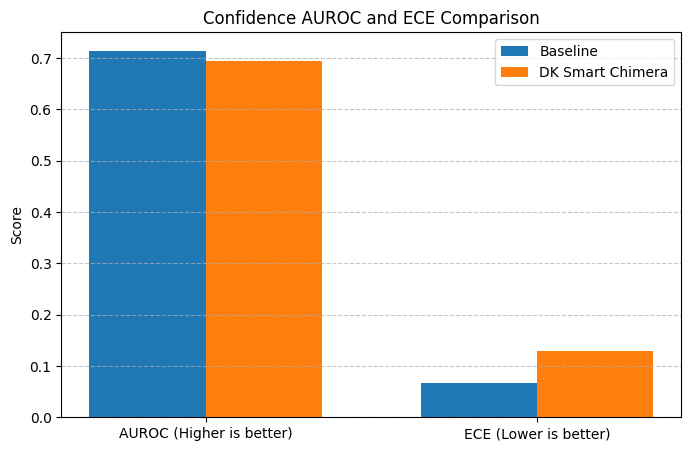

In [70]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['AUROC (Higher is better)', 'ECE (Lower is better)']
baseline_scores = [baseline_auroc, baseline_ece]
dk_scores = [dk_auroc_conf, dk_ece_conf]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, baseline_scores, width, label='Baseline')
ax.bar(x + width/2, dk_scores, width, label='DK Smart Chimera')

ax.set_ylabel('Score')
ax.set_title('Confidence AUROC and ECE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [71]:
coverage_comparison = pd.concat([baseline_coverage_table, dk_coverage_table], ignore_index=True)
coverage_comparison

,method,target_coverage,threshold,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_effective_accuracy,test_dk_rate
0,Baseline confidence threshold,1.0,0.263726,1.000000,0.485304,0.999858,0.487322,0.487253,0.000142
1,Baseline confidence threshold,0.9,0.334771,0.900065,0.503628,0.903646,0.509102,0.460048,0.096354
2,Baseline confidence threshold,0.8,0.369562,0.800131,0.528163,0.808930,0.532441,0.430708,0.191070
3,Baseline confidence threshold,0.7,0.402748,0.699543,0.563025,0.705597,0.562374,0.396810,0.294403
4,Baseline confidence threshold,0.6,0.436079,0.600261,0.601741,0.606680,0.598779,0.363267,0.393320
5,Baseline confidence threshold,0.5,0.487632,0.500327,0.640992,0.502136,0.644873,0.323814,0.497864
6,Baseline confidence threshold,0.4,0.554656,0.400392,0.683524,0.399729,0.688580,0.275246,0.600271
7,Baseline confidence threshold,0.3,0.637985,0.300457,0.732609,0.305227,0.748950,0.228600,0.694773
8,Baseline confidence threshold,0.2,0.766990,0.200523,0.801303,0.198191,0.826446,0.163794,0.801809
9,Baseline confidence threshold,0.1,0.905435,0.100588,0.883117,0.090443,0.929134,0.084034,0.909557


# Graphs

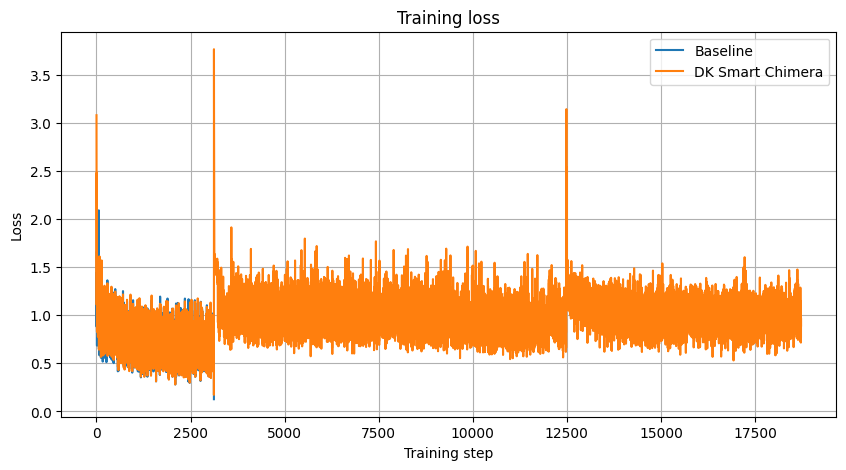

In [72]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(baseline_loss_history) + 1), baseline_loss_history, label="Baseline")
plt.plot(np.arange(1, len(dk_loss_history) + 1), dk_loss_history, label="DK Smart Chimera")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

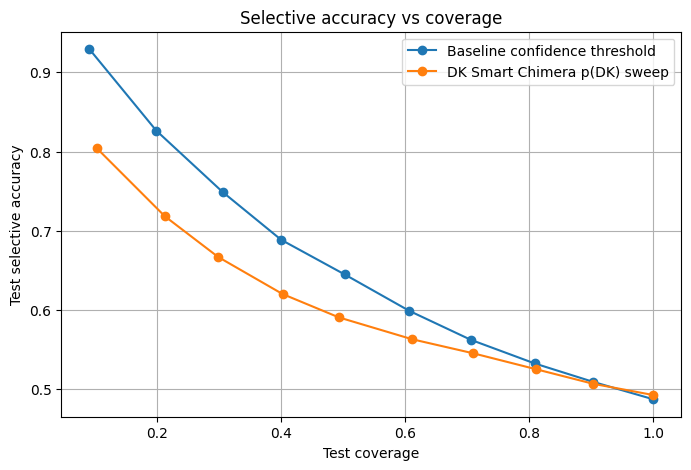

In [73]:
plt.figure(figsize=(8, 5))
for method_name, df in coverage_comparison.groupby("method"):
    plt.plot(df["test_coverage"], df["test_selective_accuracy"], marker="o", label=method_name)
plt.xlabel("Test coverage")
plt.ylabel("Test selective accuracy")
plt.title("Selective accuracy vs coverage")
plt.legend()
plt.grid(True)
plt.show()

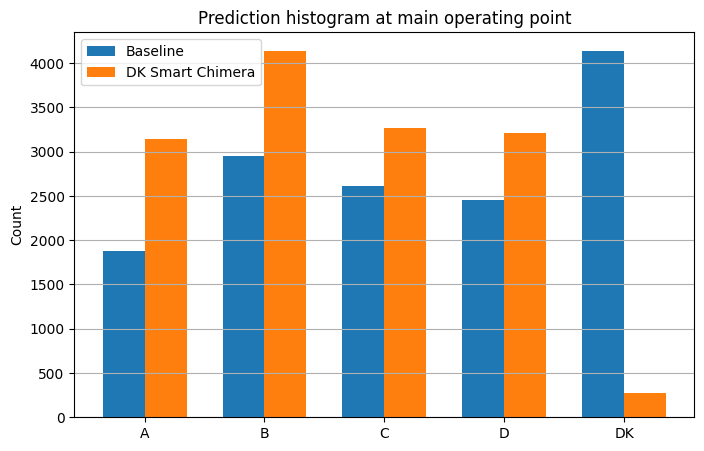

In [74]:
labels = ["A", "B", "C", "D", "DK"]

baseline_counts = np.bincount(baseline_main["final_preds"].numpy(), minlength=5)
dk_counts = np.bincount(dk_argmax_main["final_preds"].numpy(), minlength=5)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, baseline_counts, width, label="Baseline")
plt.bar(x + width / 2, dk_counts, width, label="DK Smart Chimera")
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Prediction histogram at main operating point")
plt.legend()
plt.grid(axis="y")
plt.show()

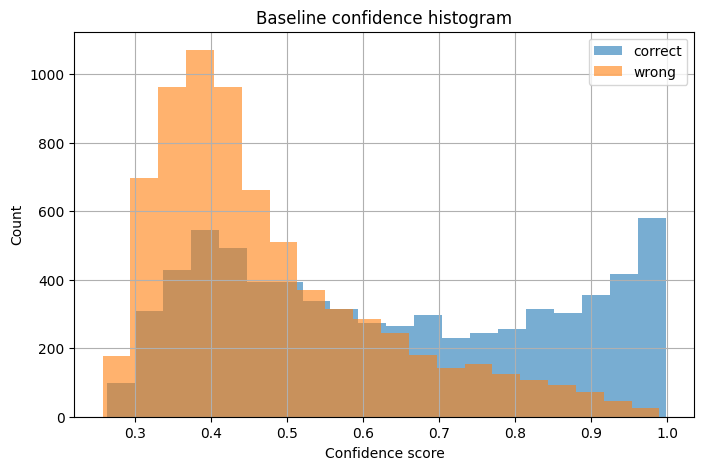

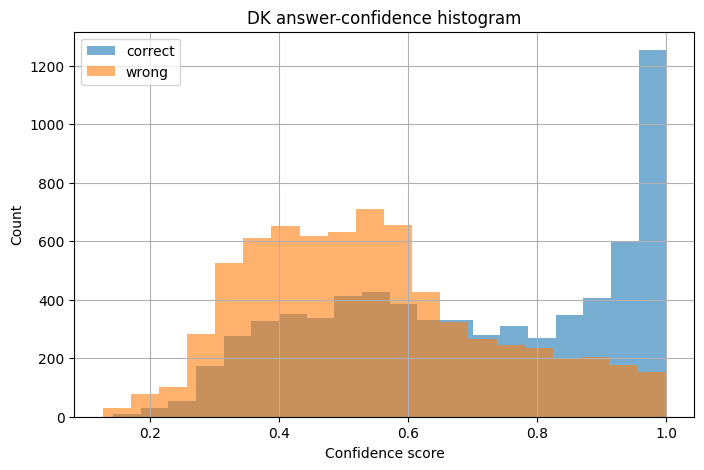

In [75]:
def plot_confidence_hist(outputs, title, score_key="conf"):
    conf = outputs[score_key].numpy()
    correct = (outputs["preds"].numpy() == outputs["labels"].numpy())

    plt.figure(figsize=(8, 5))
    plt.hist(conf[correct], bins=20, alpha=0.6, label="correct")
    plt.hist(conf[~correct], bins=20, alpha=0.6, label="wrong")
    plt.xlabel("Confidence score")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_confidence_hist(baseline_test_outputs, "Baseline confidence histogram")
plot_confidence_hist(dk_test_outputs, "DK answer-confidence histogram")

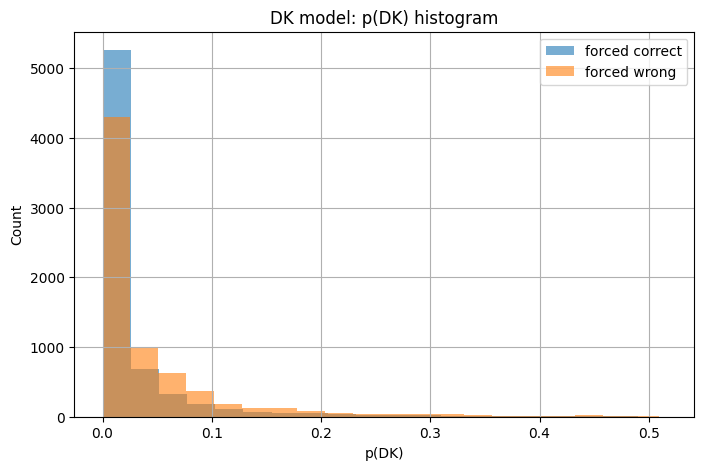

In [76]:
# Optional: DK-specific histogram for p(DK)
plt.figure(figsize=(8, 5))
p_dk = dk_test_outputs["p_dk"].numpy()
correct = (dk_test_outputs["preds"].numpy() == dk_test_outputs["labels"].numpy())
plt.hist(p_dk[correct], bins=20, alpha=0.6, label="forced correct")
plt.hist(p_dk[~correct], bins=20, alpha=0.6, label="forced wrong")
plt.xlabel("p(DK)")
plt.ylabel("Count")
plt.title("DK model: p(DK) histogram")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
def calibration_table(outputs, score_key="conf", n_bins=10):
    labels = outputs["labels"].numpy()
    preds = outputs["preds"].numpy()
    conf = outputs[score_key].numpy()
    correct = (preds == labels).astype(float)

    rows = []
    bins = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if mask.sum() == 0:
            continue
        rows.append({
            "bin": f"[{lo:.1f}, {hi:.1f}]",
            "count": int(mask.sum()),
            "avg_confidence": float(conf[mask].mean()),
            "accuracy": float(correct[mask].mean()),
            "gap": float(abs(conf[mask].mean() - correct[mask].mean())),
        })
    return pd.DataFrame(rows)

baseline_calibration = calibration_table(baseline_test_outputs, score_key="conf", n_bins=10)
dk_calibration = calibration_table(dk_test_outputs, score_key="conf", n_bins=10)

print("Baseline calibration")
display(baseline_calibration)
print("DK calibration")
display(dk_calibration)

Baseline calibration


,bin,count,avg_confidence,accuracy,gap
0,"[0.2, 0.3]",377,0.288276,0.262599,0.025677
1,"[0.3, 0.4]",3646,0.355578,0.311026,0.044552
2,"[0.4, 0.5]",3284,0.444093,0.367235,0.076858
3,"[0.5, 0.6]",1868,0.546226,0.489829,0.056398
4,"[0.6, 0.7]",1380,0.647841,0.549275,0.098566
5,"[0.7, 0.8]",1048,0.750282,0.627863,0.122419
6,"[0.8, 0.9]",1103,0.850591,0.765186,0.085405
7,"[0.9, 1.0]",1336,0.953397,0.919910,0.033487


DK calibration


,bin,count,avg_confidence,accuracy,gap
0,"[0.1, 0.2]",88,0.174310,0.227273,0.052963
1,"[0.2, 0.3]",593,0.265299,0.288364,0.023065
2,"[0.3, 0.4]",1999,0.353017,0.343172,0.009846
3,"[0.4, 0.5]",2277,0.449873,0.358366,0.091507
4,"[0.5, 0.6]",2523,0.549315,0.384463,0.164852
5,"[0.6, 0.7]",1665,0.646382,0.474474,0.171908
6,"[0.7, 0.8]",1248,0.749310,0.545673,0.203637
7,"[0.8, 0.9]",1286,0.852214,0.621306,0.230907
8,"[0.9, 1.0]",2363,0.961167,0.839187,0.121980



# Extra comparison experiments

These cells add stronger comparison experiments between:

- **Baseline:** regular model + confidence threshold
- **DK Smart Chimera:** DK model with several possible confidence / abstention scores

The most important idea is to compare the methods at the **same coverage** or the **same required selective accuracy**, not only at one arbitrary operating point.


In [78]:

# =========================================================
# Extra experiment utilities
# =========================================================

EXTRA_TARGET_COVERAGES = [1.0, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60,
                          0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
EXTRA_TARGET_ACCURACIES = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
LABEL_NAMES_5 = ["A", "B", "C", "D", "DK"]


def ensure_extra_scores(outputs, prefix=""):
    """Add extra confidence scores to an outputs dict in-place and return it."""
    outputs = dict(outputs)

    # Entropy-based confidence: lower entropy = more confident, so confidence = 1 - normalized entropy.
    probs = outputs["probs"].float().clamp(min=1e-12)
    entropy = -(probs * probs.log()).sum(dim=1)
    max_entropy = np.log(probs.shape[1])
    outputs["entropy_conf"] = 1.0 - entropy / max_entropy

    if "p_dk" in outputs:
        # Raw answer confidence over the 5-way softmax: max p(A/B/C/D)
        outputs["raw_answer_conf"] = outputs["conf"]

        # Confidence that the model should answer, based only on DK probability.
        outputs["one_minus_pdk"] = 1.0 - outputs["p_dk"]

        # Margin between best answer class and DK.
        outputs["margin_conf"] = outputs["conf"] - outputs["p_dk"]

        # Conditional answer confidence among A/B/C/D after removing DK mass.
        denom = (1.0 - outputs["p_dk"]).clamp(min=1e-8)
        outputs["conditional_conf"] = (outputs["conf"] / denom).clamp(max=1.0)

        # A conservative score that is high only when answer confidence is high and DK is low.
        outputs["product_conf"] = outputs["conditional_conf"] * outputs["one_minus_pdk"]

    return outputs


baseline_val_extra = ensure_extra_scores(baseline_val_outputs)
baseline_test_extra = ensure_extra_scores(baseline_test_outputs)
dk_val_extra = ensure_extra_scores(dk_val_outputs)
dk_test_extra = ensure_extra_scores(dk_test_outputs)


def threshold_for_target_coverage_np(scores, target_coverage):
    scores_np = scores.detach().cpu().numpy() if torch.is_tensor(scores) else np.asarray(scores)
    return float(np.quantile(scores_np, 1.0 - target_coverage))


def apply_score_threshold(outputs, score_key, threshold):
    labels = outputs["labels"]
    preds = outputs["preds"]
    scores = outputs[score_key]
    should_answer = scores >= threshold
    final_preds = preds.clone()
    final_preds[~should_answer] = 4
    return compute_operating_metrics(labels, preds, should_answer, final_preds, threshold=threshold)


def build_score_coverage_table(val_outputs, test_outputs, score_key, method_name, target_coverages=EXTRA_TARGET_COVERAGES):
    rows = []
    for target_cov in target_coverages:
        tau = threshold_for_target_coverage_np(val_outputs[score_key], target_cov)
        val_m = apply_score_threshold(val_outputs, score_key, tau)
        test_m = apply_score_threshold(test_outputs, score_key, tau)
        rows.append({
            "method": method_name,
            "score_key": score_key,
            "target_coverage": target_cov,
            "threshold_from_val": tau,
            "val_coverage": val_m["coverage"],
            "val_selective_accuracy": val_m["selective_accuracy"],
            "test_coverage": test_m["coverage"],
            "test_selective_accuracy": test_m["selective_accuracy"],
            "test_risk": 1.0 - test_m["selective_accuracy"] if not np.isnan(test_m["selective_accuracy"]) else np.nan,
            "test_effective_accuracy": test_m["effective_accuracy"],
            "test_dk_rate": test_m["dk_rate"],
            "test_answered": test_m["answered"],
            "test_dk": test_m["dk"],
        })
    return pd.DataFrame(rows)


def compute_aurc_from_table(df):
    """Area under risk-coverage curve. Lower is better."""
    tmp = df[["test_coverage", "test_risk"]].dropna().sort_values("test_coverage")
    if len(tmp) < 2:
        return np.nan
    return float(np.trapz(tmp["test_risk"].values, tmp["test_coverage"].values))


def rejection_quality(outputs, operating_metrics, method_name):
    labels = outputs["labels"]
    preds = outputs["preds"]
    forced_correct = preds == labels
    should_answer = operating_metrics["should_answer"]
    rejected = ~should_answer

    forced_wrong = ~forced_correct
    wrong_rejected = (rejected & forced_wrong).sum().item()
    correct_rejected = (rejected & forced_correct).sum().item()
    total_wrong = forced_wrong.sum().item()
    total_correct = forced_correct.sum().item()
    total_rejected = rejected.sum().item()

    return {
        "method": method_name,
        "coverage": operating_metrics["coverage"],
        "selective_accuracy": operating_metrics["selective_accuracy"],
        "reject_wrong_rate": wrong_rejected / total_wrong if total_wrong else np.nan,
        "reject_correct_rate": correct_rejected / total_correct if total_correct else np.nan,
        "dk_precision_wrong_among_rejected": wrong_rejected / total_rejected if total_rejected else np.nan,
        "rejected_count": total_rejected,
        "wrong_rejected": wrong_rejected,
        "correct_rejected": correct_rejected,
    }


def confusion_matrix_final(outputs, operating_metrics):
    true = outputs["labels"].detach().cpu().numpy()
    pred = operating_metrics["final_preds"].detach().cpu().numpy()
    cm = pd.crosstab(
        pd.Categorical([LABEL_NAMES_5[i] for i in true], categories=LABEL_NAMES_5),
        pd.Categorical([LABEL_NAMES_5[i] for i in pred], categories=LABEL_NAMES_5),
        rownames=["true"], colnames=["pred"], dropna=False,
    )
    return cm



## 1. Score comparison for DK

For the DK model, `p(DK)` is only one possible uncertainty signal. We compare several scores:

- `raw_answer_conf = max p(A/B/C/D)` using the 5-way softmax
- `one_minus_pdk = 1 - p(DK)`
- `margin_conf = max p(A/B/C/D) - p(DK)`
- `conditional_conf = max p(A/B/C/D) / (1 - p(DK))`
- `product_conf = conditional_conf * (1 - p(DK))`

Higher score means **more willing to answer**.


,method,score,score_key,AUROC_higher_better,ECE_lower_better
0,Baseline,Baseline max softmax confidence,conf,0.714390,0.066465
1,Baseline,Baseline entropy confidence,entropy_conf,0.709015,0.225619
7,DK Smart Chimera,DK entropy confidence,entropy_conf,0.696277,0.107531
5,DK Smart Chimera,DK conditional answer conf,conditional_conf,0.694549,0.143078
6,DK Smart Chimera,DK conditional_conf * (1-pDK),product_conf,0.694289,0.128881
2,DK Smart Chimera,DK raw answer conf,raw_answer_conf,0.694289,0.128881
4,DK Smart Chimera,DK max_answer - p(DK),margin_conf,0.693041,NaN
3,DK Smart Chimera,DK 1 - p(DK),one_minus_pdk,0.643056,0.470647


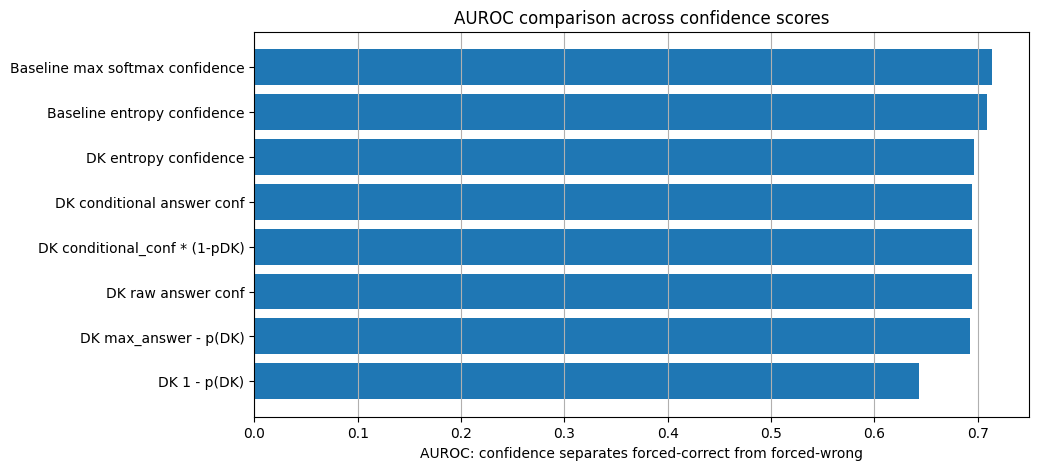

In [79]:

# =========================================================
# 1. AUROC / ECE for different confidence scores
# =========================================================

score_rows = []

# Baseline scores
for key, nice_name in [
    ("conf", "Baseline max softmax confidence"),
    ("entropy_conf", "Baseline entropy confidence"),
]:
    score_rows.append({
        "method": "Baseline",
        "score": nice_name,
        "score_key": key,
        "AUROC_higher_better": compute_auroc(baseline_test_extra, score_key=key),
        "ECE_lower_better": compute_ece(baseline_test_extra, score_key=key, n_bins=15),
    })

# DK scores
for key, nice_name in [
    ("raw_answer_conf", "DK raw answer conf"),
    ("one_minus_pdk", "DK 1 - p(DK)"),
    ("margin_conf", "DK max_answer - p(DK)"),
    ("conditional_conf", "DK conditional answer conf"),
    ("product_conf", "DK conditional_conf * (1-pDK)"),
    ("entropy_conf", "DK entropy confidence"),
]:
    # ECE is meaningful only for scores roughly in [0,1]. margin_conf can be negative, so skip ECE there.
    ece = np.nan if key == "margin_conf" else compute_ece(dk_test_extra, score_key=key, n_bins=15)
    score_rows.append({
        "method": "DK Smart Chimera",
        "score": nice_name,
        "score_key": key,
        "AUROC_higher_better": compute_auroc(dk_test_extra, score_key=key),
        "ECE_lower_better": ece,
    })

score_comparison = pd.DataFrame(score_rows).sort_values("AUROC_higher_better", ascending=False)
display(score_comparison)

plt.figure(figsize=(10, 5))
plt.barh(score_comparison["score"], score_comparison["AUROC_higher_better"])
plt.xlabel("AUROC: confidence separates forced-correct from forced-wrong")
plt.title("AUROC comparison across confidence scores")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.show()



## 2. Selective accuracy vs coverage, with more DK decision rules

This is the main fair comparison:

> At the same coverage, which method has higher selective accuracy?


,method,score_key,target_coverage,threshold_from_val,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_risk,test_effective_accuracy,test_dk_rate,test_answered,test_dk
0,Baseline: max confidence,conf,1.00,0.263726,1.000000,0.485304,0.999858,0.487322,0.512678,0.487253,0.000142,14040,2
1,Baseline: max confidence,conf,0.95,0.312777,0.949706,0.493810,0.952144,0.498654,0.501346,0.474790,0.047856,13370,672
2,Baseline: max confidence,conf,0.90,0.334771,0.900065,0.503628,0.903646,0.509102,0.490898,0.460048,0.096354,12689,1353
3,Baseline: max confidence,conf,0.85,0.353067,0.849771,0.515757,0.856787,0.520655,0.479345,0.446090,0.143213,12031,2011
4,Baseline: max confidence,conf,0.80,0.369562,0.800131,0.528163,0.808930,0.532441,0.467559,0.430708,0.191070,11359,2683
5,Baseline: max confidence,conf,0.75,0.386055,0.749837,0.542683,0.756872,0.546857,0.453143,0.413901,0.243128,10628,3414
6,Baseline: max confidence,conf,0.70,0.402748,0.699543,0.563025,0.705597,0.562374,0.437626,0.396810,0.294403,9908,4134
7,Baseline: max confidence,conf,0.65,0.419451,0.649902,0.582915,0.654964,0.579102,0.420898,0.379291,0.345036,9197,4845
8,Baseline: max confidence,conf,0.60,0.436079,0.600261,0.601741,0.606680,0.598779,0.401221,0.363267,0.393320,8519,5523
9,Baseline: max confidence,conf,0.55,0.458622,0.549967,0.623515,0.556117,0.620566,0.379434,0.345108,0.443883,7809,6233


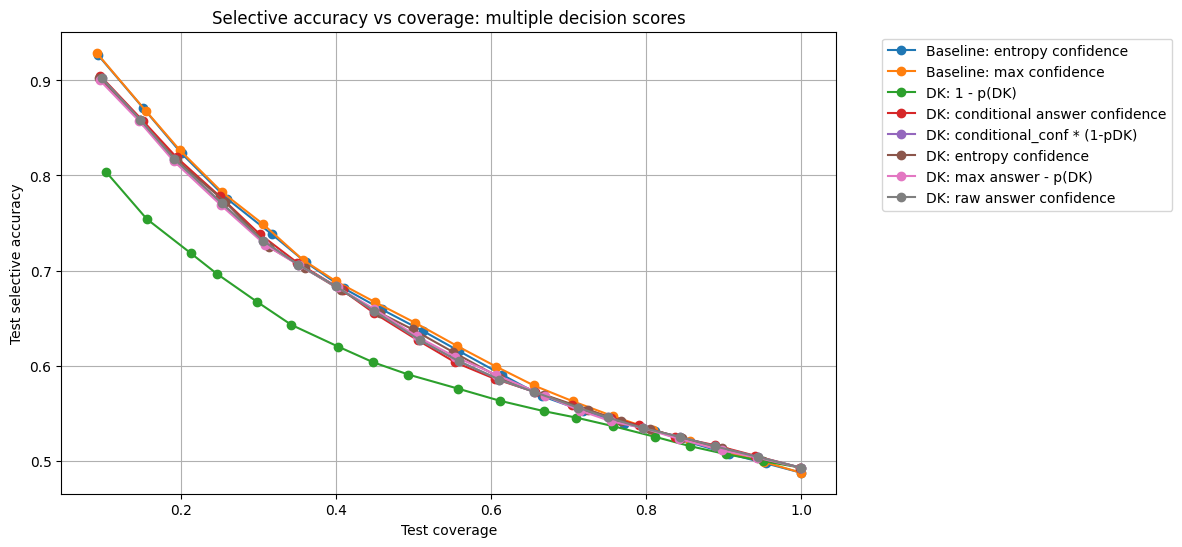

In [80]:

# =========================================================
# 2. Selective accuracy vs coverage for multiple methods/scores
# =========================================================

advanced_tables = []
advanced_tables.append(build_score_coverage_table(
    baseline_val_extra, baseline_test_extra, "conf", "Baseline: max confidence"
))
advanced_tables.append(build_score_coverage_table(
    baseline_val_extra, baseline_test_extra, "entropy_conf", "Baseline: entropy confidence"
))

for score_key, method_name in [
    ("raw_answer_conf", "DK: raw answer confidence"),
    ("one_minus_pdk", "DK: 1 - p(DK)"),
    ("margin_conf", "DK: max answer - p(DK)"),
    ("conditional_conf", "DK: conditional answer confidence"),
    ("product_conf", "DK: conditional_conf * (1-pDK)"),
    ("entropy_conf", "DK: entropy confidence"),
]:
    advanced_tables.append(build_score_coverage_table(
        dk_val_extra, dk_test_extra, score_key, method_name
    ))

advanced_coverage_comparison = pd.concat(advanced_tables, ignore_index=True)
display(advanced_coverage_comparison.head(20))

plt.figure(figsize=(10, 6))
for method_name, df in advanced_coverage_comparison.groupby("method"):
    df = df.sort_values("test_coverage")
    plt.plot(df["test_coverage"], df["test_selective_accuracy"], marker="o", label=method_name)
plt.xlabel("Test coverage")
plt.ylabel("Test selective accuracy")
plt.title("Selective accuracy vs coverage: multiple decision scores")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()



## 3. Risk-coverage curve and AURC

Risk is error among answered examples:

```text
risk = 1 - selective_accuracy
```

Lower curve is better. Lower **AURC** is better.


/tmp/ipykernel_943/2936703205.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tmp["test_risk"].values, tmp["test_coverage"].values))
/tmp/ipykernel_943/2936703205.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tmp["test_risk"].values, tmp["test_coverage"].values))
/tmp/ipykernel_943/2936703205.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tmp["test_risk"].values, tmp["test_coverage"].values))
/tmp/ipykernel_943/2936703205.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tmp["test_risk"].values, tmp["test_coverage"].v

,method,AURC_lower_better,best_selective_accuracy_seen,max_coverage_seen
1,Baseline: max confidence,0.318708,0.929134,0.999858
0,Baseline: entropy confidence,0.320971,0.926324,0.999715
5,DK: entropy confidence,0.324247,0.902347,0.999003
3,DK: conditional answer confidence,0.324412,0.905011,0.998718
7,DK: raw answer confidence,0.325470,0.902493,0.999786
4,DK: conditional_conf * (1-pDK),0.325470,0.902493,0.999786
6,DK: max answer - p(DK),0.326206,0.900075,0.999573
2,DK: 1 - p(DK),0.360291,0.804031,0.999501


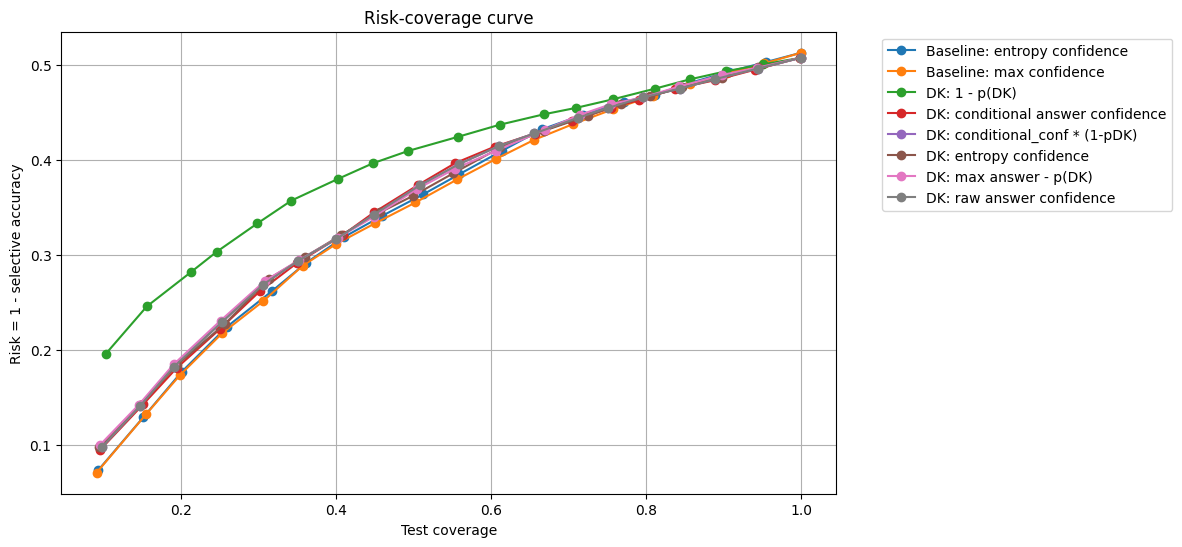

In [81]:

# =========================================================
# 3. Risk-coverage and AURC
# =========================================================

aurc_rows = []
for method_name, df in advanced_coverage_comparison.groupby("method"):
    aurc_rows.append({
        "method": method_name,
        "AURC_lower_better": compute_aurc_from_table(df),
        "best_selective_accuracy_seen": df["test_selective_accuracy"].max(),
        "max_coverage_seen": df["test_coverage"].max(),
    })

aurc_table = pd.DataFrame(aurc_rows).sort_values("AURC_lower_better")
display(aurc_table)

plt.figure(figsize=(10, 6))
for method_name, df in advanced_coverage_comparison.groupby("method"):
    df = df.sort_values("test_coverage")
    plt.plot(df["test_coverage"], df["test_risk"], marker="o", label=method_name)
plt.xlabel("Test coverage")
plt.ylabel("Risk = 1 - selective accuracy")
plt.title("Risk-coverage curve")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()



## 4. Coverage at fixed selective accuracy

This answers:

> If I require 80% accuracy, how many questions can each method answer?


,method,target_selective_accuracy,best_test_coverage_at_or_above_target,actual_selective_accuracy,threshold_from_val
0,Baseline: entropy confidence,0.60,0.558895,0.615061,0.129584
1,Baseline: entropy confidence,0.65,0.458624,0.659161,0.179193
2,Baseline: entropy confidence,0.70,0.360561,0.708671,0.259514
3,Baseline: entropy confidence,0.75,0.259080,0.775426,0.369287
4,Baseline: entropy confidence,0.80,0.200185,0.823195,0.463076
5,Baseline: entropy confidence,0.85,0.150691,0.870983,0.563420
6,Baseline: entropy confidence,0.90,0.092793,0.926324,0.709452
7,Baseline: max confidence,0.60,0.556117,0.620566,0.458622
8,Baseline: max confidence,0.65,0.450292,0.666614,0.517365
9,Baseline: max confidence,0.70,0.356573,0.711404,0.590958


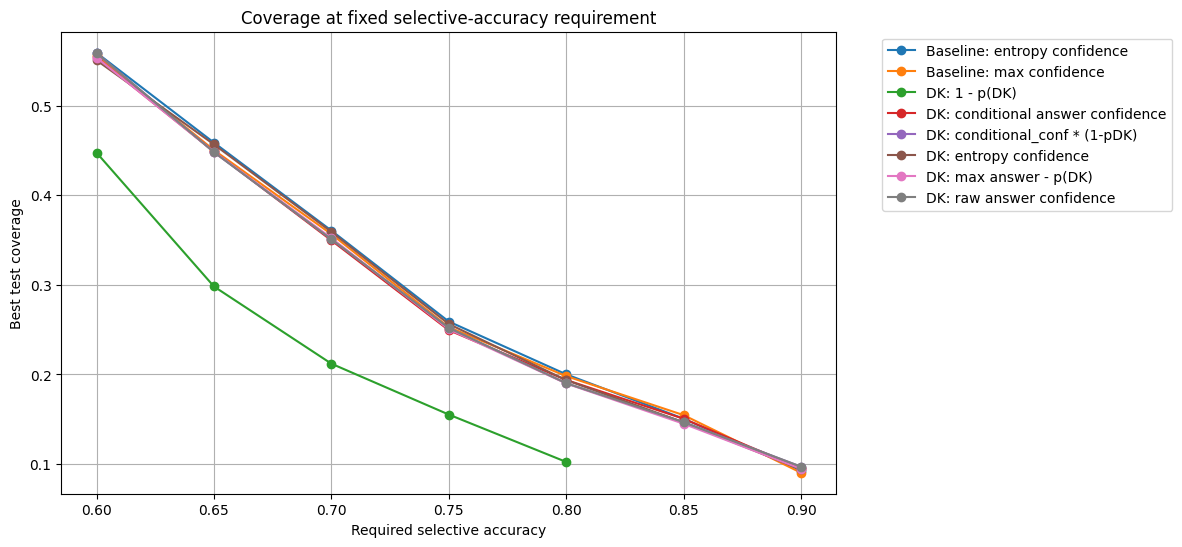

In [82]:

# =========================================================
# 4. Coverage at fixed selective accuracy
# =========================================================

fixed_acc_rows = []
for method_name, df in advanced_coverage_comparison.groupby("method"):
    for target_acc in EXTRA_TARGET_ACCURACIES:
        ok = df[df["test_selective_accuracy"] >= target_acc]
        if len(ok) == 0:
            row = {
                "method": method_name,
                "target_selective_accuracy": target_acc,
                "best_test_coverage_at_or_above_target": np.nan,
                "actual_selective_accuracy": np.nan,
                "threshold_from_val": np.nan,
            }
        else:
            best = ok.sort_values("test_coverage", ascending=False).iloc[0]
            row = {
                "method": method_name,
                "target_selective_accuracy": target_acc,
                "best_test_coverage_at_or_above_target": best["test_coverage"],
                "actual_selective_accuracy": best["test_selective_accuracy"],
                "threshold_from_val": best["threshold_from_val"],
            }
        fixed_acc_rows.append(row)

coverage_at_fixed_accuracy = pd.DataFrame(fixed_acc_rows)
display(coverage_at_fixed_accuracy)

plt.figure(figsize=(10, 6))
for method_name, df in coverage_at_fixed_accuracy.groupby("method"):
    plt.plot(df["target_selective_accuracy"], df["best_test_coverage_at_or_above_target"], marker="o", label=method_name)
plt.xlabel("Required selective accuracy")
plt.ylabel("Best test coverage")
plt.title("Coverage at fixed selective-accuracy requirement")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()



## 5. Selective accuracy at fixed coverage

This table is usually the easiest to explain in the report.


In [83]:

# =========================================================
# 5. Selective accuracy at fixed coverage
# =========================================================

fixed_coverage_table = advanced_coverage_comparison[[
    "method", "target_coverage", "test_coverage", "test_selective_accuracy", "test_effective_accuracy", "test_dk_rate"
]].copy()

fixed_coverage_pivot = fixed_coverage_table.pivot_table(
    index="target_coverage",
    columns="method",
    values="test_selective_accuracy",
    aggfunc="first"
).sort_index(ascending=False)

display(fixed_coverage_pivot)

# Optional compact winner table
winner_rows = []
for target_cov, row in fixed_coverage_pivot.iterrows():
    best_method = row.astype(float).idxmax()
    winner_rows.append({
        "target_coverage": target_cov,
        "best_method_by_test_selective_accuracy": best_method,
        "best_selective_accuracy": row[best_method],
    })
fixed_coverage_winners = pd.DataFrame(winner_rows)
display(fixed_coverage_winners)


method,Baseline: entropy confidence,Baseline: max confidence,DK: 1 - p(DK),DK: conditional answer confidence,DK: conditional_conf * (1-pDK),DK: entropy confidence,DK: max answer - p(DK),DK: raw answer confidence
target_coverage,,,,,,,,
1.00,0.487391,0.487322,0.492697,0.492655,0.492628,0.492729,0.492662,0.492628
0.95,0.497165,0.498654,0.499438,0.505148,0.503999,0.502790,0.503325,0.503999
0.90,0.507222,0.509102,0.506739,0.516310,0.515059,0.513413,0.510834,0.515059
0.85,0.519128,0.520655,0.515346,0.525228,0.525173,0.523898,0.522816,0.525173
0.80,0.531519,0.532441,0.525101,0.537311,0.534342,0.533097,0.534210,0.534342
0.75,0.538959,0.546857,0.536305,0.545403,0.545575,0.541326,0.541431,0.545575
0.70,0.552548,0.562374,0.545318,0.558669,0.555700,0.553764,0.552676,0.555700
0.65,0.567987,0.579102,0.552073,0.572343,0.572220,0.569403,0.568463,0.572220
0.60,0.590329,0.598779,0.563068,0.586101,0.585366,0.586941,0.590391,0.585366


,target_coverage,best_method_by_test_selective_accuracy,best_selective_accuracy
0,1.00,DK: entropy confidence,0.492729
1,0.95,DK: conditional answer confidence,0.505148
2,0.90,DK: conditional answer confidence,0.516310
3,0.85,DK: conditional answer confidence,0.525228
4,0.80,DK: conditional answer confidence,0.537311
5,0.75,Baseline: max confidence,0.546857
6,0.70,Baseline: max confidence,0.562374
7,0.65,Baseline: max confidence,0.579102
8,0.60,Baseline: max confidence,0.598779
9,0.55,Baseline: max confidence,0.620566



## 6. Correct rejection vs wrong rejection

A good abstention method should reject many **forced-wrong** examples and few **forced-correct** examples.


,method,coverage,selective_accuracy,reject_wrong_rate,reject_correct_rate,dk_precision_wrong_among_rejected,rejected_count,wrong_rejected,correct_rejected
0,Baseline max confidence @ 70% target coverage,0.705597,0.562374,0.397694,0.185737,0.692550,4134,2863,1271
1,DK argmax-only,0.980202,0.496803,0.028066,0.011278,0.719424,278,200,78
2,DK raw answer conf @ 70% target coverage,0.712149,0.555700,0.376509,0.196501,0.663780,4042,2683,1359
3,DK 1 - p(DK) @ 70% target coverage,0.709514,0.545318,0.364300,0.214430,0.636430,4079,2596,1483
4,DK margin @ 70% target coverage,0.714499,0.552676,0.370194,0.198236,0.658019,4009,2638,1371
5,DK conditional conf @ 70% target coverage,0.704031,0.558669,0.387735,0.201417,0.664822,4156,2763,1393
6,DK product conf @ 70% target coverage,0.712149,0.555700,0.376509,0.196501,0.663780,4042,2683,1359


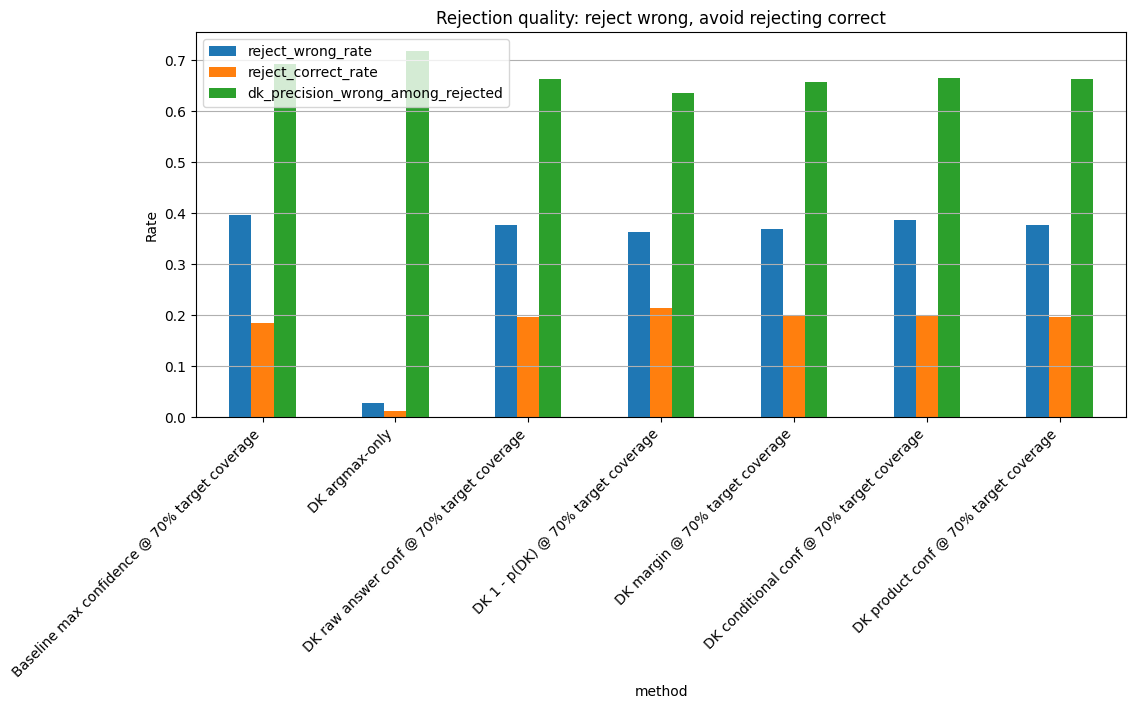

In [84]:

# =========================================================
# 6. Rejection quality at 70% target coverage and at DK argmax
# =========================================================

REJECTION_TARGET_COVERAGE = 0.70
rejection_rows = []

# Baseline at target coverage
base_tau = threshold_for_target_coverage_np(baseline_val_extra["conf"], REJECTION_TARGET_COVERAGE)
base_m = apply_score_threshold(baseline_test_extra, "conf", base_tau)
rejection_rows.append(rejection_quality(baseline_test_extra, base_m, f"Baseline max confidence @ {REJECTION_TARGET_COVERAGE:.0%} target coverage"))

# DK argmax, no threshold
rejection_rows.append(rejection_quality(dk_test_extra, dk_argmax_main, "DK argmax-only"))

# DK score-based rules at same target coverage
for score_key, method_name in [
    ("raw_answer_conf", "DK raw answer conf"),
    ("one_minus_pdk", "DK 1 - p(DK)"),
    ("margin_conf", "DK margin"),
    ("conditional_conf", "DK conditional conf"),
    ("product_conf", "DK product conf"),
]:
    tau = threshold_for_target_coverage_np(dk_val_extra[score_key], REJECTION_TARGET_COVERAGE)
    m = apply_score_threshold(dk_test_extra, score_key, tau)
    rejection_rows.append(rejection_quality(dk_test_extra, m, f"{method_name} @ {REJECTION_TARGET_COVERAGE:.0%} target coverage"))

rejection_quality_table = pd.DataFrame(rejection_rows)
display(rejection_quality_table)

plot_cols = ["reject_wrong_rate", "reject_correct_rate", "dk_precision_wrong_among_rejected"]
rejection_quality_table.set_index("method")[plot_cols].plot(kind="bar", figsize=(12, 5))
plt.ylabel("Rate")
plt.title("Rejection quality: reject wrong, avoid rejecting correct")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()



## 7. Confusion matrices with DK / abstain

For the baseline, `DK` means threshold abstention.  
For Smart Chimera, `DK` can mean either real argmax DK or threshold abstention depending on the rule.


In [85]:

# =========================================================
# 7. Confusion matrix including DK
# =========================================================

print("Baseline confusion matrix @ 70% target coverage")
display(confusion_matrix_final(baseline_test_extra, base_m))

print("DK argmax-only confusion matrix")
display(confusion_matrix_final(dk_test_extra, dk_argmax_main))

# Also show the best DK score at 70% target coverage according to AUROC.
best_dk_score_key = score_comparison[score_comparison["method"] == "DK Smart Chimera"].iloc[0]["score_key"]
best_dk_tau = threshold_for_target_coverage_np(dk_val_extra[best_dk_score_key], REJECTION_TARGET_COVERAGE)
best_dk_m = apply_score_threshold(dk_test_extra, best_dk_score_key, best_dk_tau)
print(f"Best DK score by AUROC at 70% target coverage: {best_dk_score_key}")
display(confusion_matrix_final(dk_test_extra, best_dk_m))


Baseline confusion matrix @ 70% target coverage


pred,A,B,C,D,DK
true,,,,,
A,1084,465,394,309,970
B,276,1509,363,297,1017
C,267,495,1443,314,1063
D,251,487,418,1536,1084
DK,0,0,0,0,0


DK argmax-only confusion matrix


pred,A,B,C,D,DK
true,,,,,
A,1519,696,510,433,64
B,556,1856,493,481,76
C,544,795,1668,503,72
D,528,795,592,1795,66
DK,0,0,0,0,0


Best DK score by AUROC at 70% target coverage: entropy_conf


pred,A,B,C,D,DK
true,,,,,
A,1273,485,312,277,875
B,381,1524,305,293,959
C,348,527,1356,328,1023
D,338,564,382,1481,1011
DK,0,0,0,0,0



## 8. Per-subject MMLU analysis

This checks whether DK helps more on hard subjects and whether DK rate rises when the subject is harder.


,method,subject,n,forced_accuracy,coverage,dk_rate,selective_accuracy
43,Baseline @ 70% target coverage,moral_scenarios,895,0.240223,0.461453,0.538547,0.198547
0,Baseline @ 70% target coverage,abstract_algebra,100,0.290000,0.300000,0.700000,0.400000
17,Baseline @ 70% target coverage,global_facts,100,0.310000,0.120000,0.880000,0.416667
13,Baseline @ 70% target coverage,econometrics,114,0.315789,0.684211,0.315789,0.346154
27,Baseline @ 70% target coverage,high_school_physics,151,0.344371,0.549669,0.450331,0.397590
48,Baseline @ 70% target coverage,professional_law,1534,0.351369,0.476532,0.523468,0.402189
8,Baseline @ 70% target coverage,college_mathematics,100,0.370000,0.370000,0.630000,0.513514
10,Baseline @ 70% target coverage,college_physics,102,0.372549,0.450980,0.549020,0.543478
7,Baseline @ 70% target coverage,college_computer_science,100,0.390000,0.580000,0.420000,0.517241
47,Baseline @ 70% target coverage,professional_accounting,282,0.390071,0.567376,0.432624,0.468750


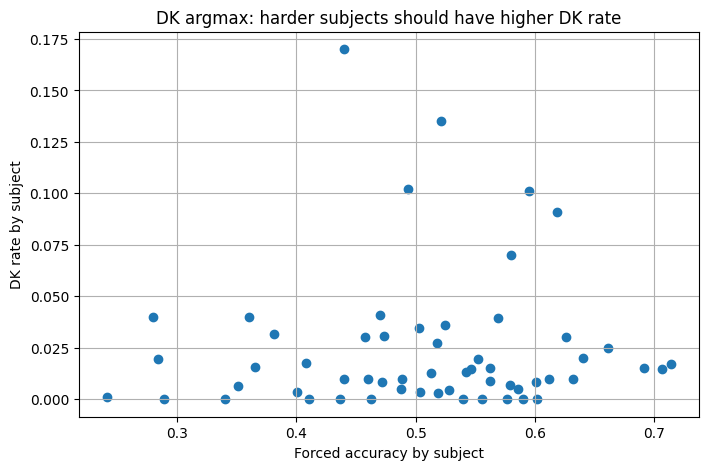

,method_baseline,subject,n_baseline,forced_accuracy_baseline,coverage_baseline,dk_rate_baseline,selective_accuracy_baseline,method_dk,n_dk,forced_accuracy_dk,coverage_dk,dk_rate_dk,selective_accuracy_dk,selective_accuracy_gain_dk_minus_baseline
3,Baseline @ 70% target coverage,business_ethics,100,0.460000,0.860000,0.140000,0.465116,DK entropy_conf @ 70% target coverage,100,0.440000,0.570000,0.430000,0.578947,0.113831
17,Baseline @ 70% target coverage,global_facts,100,0.310000,0.120000,0.880000,0.416667,DK entropy_conf @ 70% target coverage,100,0.340000,0.190000,0.810000,0.526316,0.109649
11,Baseline @ 70% target coverage,computer_security,100,0.590000,0.800000,0.200000,0.637500,DK entropy_conf @ 70% target coverage,100,0.580000,0.760000,0.240000,0.697368,0.059868
45,Baseline @ 70% target coverage,philosophy,311,0.472669,0.864952,0.135048,0.490706,DK entropy_conf @ 70% target coverage,311,0.488746,0.807074,0.192926,0.545817,0.055110
43,Baseline @ 70% target coverage,moral_scenarios,895,0.240223,0.461453,0.538547,0.198547,DK entropy_conf @ 70% target coverage,895,0.241341,0.823464,0.176536,0.248304,0.049757
35,Baseline @ 70% target coverage,jurisprudence,108,0.583333,0.805556,0.194444,0.620690,DK entropy_conf @ 70% target coverage,108,0.601852,0.759259,0.240741,0.658537,0.037847
55,Baseline @ 70% target coverage,virology,166,0.433735,0.891566,0.108434,0.472973,DK entropy_conf @ 70% target coverage,166,0.457831,0.807229,0.192771,0.507463,0.034490
7,Baseline @ 70% target coverage,college_computer_science,100,0.390000,0.580000,0.420000,0.517241,DK entropy_conf @ 70% target coverage,100,0.460000,0.580000,0.420000,0.551724,0.034483
9,Baseline @ 70% target coverage,college_medicine,173,0.456647,0.745665,0.254335,0.519380,DK entropy_conf @ 70% target coverage,173,0.502890,0.751445,0.248555,0.553846,0.034466
8,Baseline @ 70% target coverage,college_mathematics,100,0.370000,0.370000,0.630000,0.513514,DK entropy_conf @ 70% target coverage,100,0.440000,0.420000,0.580000,0.547619,0.034106


In [86]:

# =========================================================
# 8. Per-subject analysis
# =========================================================


def per_subject_metrics(outputs, operating_metrics, method_name, min_count=20):
    subjects = np.asarray(outputs.get("subjects", ["unknown"] * len(outputs["labels"])))
    labels = outputs["labels"].detach().cpu().numpy()
    preds = outputs["preds"].detach().cpu().numpy()
    should = operating_metrics["should_answer"].detach().cpu().numpy().astype(bool)
    correct = preds == labels

    rows = []
    for subject in sorted(set(subjects)):
        mask = subjects == subject
        n = int(mask.sum())
        if n < min_count:
            continue
        answered = int((mask & should).sum())
        selected_correct = int((mask & should & correct).sum())
        rows.append({
            "method": method_name,
            "subject": subject,
            "n": n,
            "forced_accuracy": float(correct[mask].mean()),
            "coverage": answered / n,
            "dk_rate": 1.0 - answered / n,
            "selective_accuracy": selected_correct / answered if answered else np.nan,
        })
    return pd.DataFrame(rows)

base_subject_table = per_subject_metrics(baseline_test_extra, base_m, "Baseline @ 70% target coverage")
dk_argmax_subject_table = per_subject_metrics(dk_test_extra, dk_argmax_main, "DK argmax-only")
dk_best_subject_table = per_subject_metrics(dk_test_extra, best_dk_m, f"DK {best_dk_score_key} @ 70% target coverage")

per_subject_table = pd.concat([base_subject_table, dk_argmax_subject_table, dk_best_subject_table], ignore_index=True)
display(per_subject_table.sort_values(["method", "forced_accuracy"]).head(30))

# Subject difficulty vs DK rate for DK argmax
plt.figure(figsize=(8, 5))
tmp = dk_argmax_subject_table.dropna(subset=["forced_accuracy", "dk_rate"])
plt.scatter(tmp["forced_accuracy"], tmp["dk_rate"])
plt.xlabel("Forced accuracy by subject")
plt.ylabel("DK rate by subject")
plt.title("DK argmax: harder subjects should have higher DK rate")
plt.grid(True)
plt.show()

# Top subjects where DK best-score beats baseline at same target coverage
merged_subjects = base_subject_table.merge(
    dk_best_subject_table,
    on="subject",
    suffixes=("_baseline", "_dk")
)
merged_subjects["selective_accuracy_gain_dk_minus_baseline"] = (
    merged_subjects["selective_accuracy_dk"] - merged_subjects["selective_accuracy_baseline"]
)
display(merged_subjects.sort_values("selective_accuracy_gain_dk_minus_baseline", ascending=False).head(20))



## 9. Oracle and random abstention baselines

These are sanity checks:

- **Random abstention:** answers a random subset. It should stay close to forced accuracy.
- **Oracle abstention:** answers correct examples first. It is an upper bound, not a real method.


,method,test_coverage,test_selective_accuracy,test_risk
0,Baseline: random abstention,1.00,0.487324,0.512676
1,Baseline: oracle abstention upper bound,1.00,0.487324,0.512676
2,Baseline: random abstention,0.95,0.487481,0.512519
3,Baseline: oracle abstention upper bound,0.95,0.512969,0.487031
4,Baseline: random abstention,0.90,0.488052,0.511948


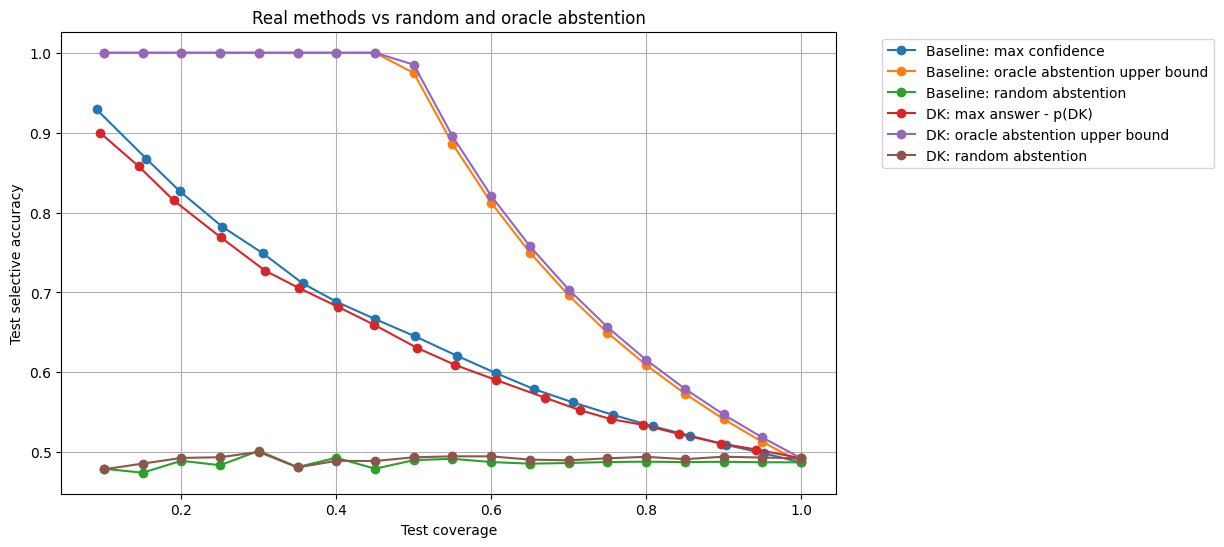

In [87]:

# =========================================================
# 9. Oracle and random abstention baselines
# =========================================================


def oracle_random_curves(outputs, method_prefix, target_coverages=EXTRA_TARGET_COVERAGES, seed=1):
    rng = np.random.default_rng(seed)
    labels = outputs["labels"].detach().cpu().numpy()
    preds = outputs["preds"].detach().cpu().numpy()
    correct = (preds == labels).astype(bool)
    n = len(correct)
    rows = []
    for cov in target_coverages:
        k = int(round(cov * n))
        k = max(0, min(n, k))

        # Random selection
        chosen = np.zeros(n, dtype=bool)
        if k > 0:
            chosen[rng.choice(n, size=k, replace=False)] = True
        rows.append({
            "method": f"{method_prefix}: random abstention",
            "test_coverage": cov,
            "test_selective_accuracy": float(correct[chosen].mean()) if k > 0 else np.nan,
            "test_risk": 1.0 - float(correct[chosen].mean()) if k > 0 else np.nan,
        })

        # Oracle selection: choose correct examples first.
        oracle_order = np.argsort(~correct)  # True correct first because ~correct is False
        oracle_chosen = np.zeros(n, dtype=bool)
        if k > 0:
            oracle_chosen[oracle_order[:k]] = True
        rows.append({
            "method": f"{method_prefix}: oracle abstention upper bound",
            "test_coverage": cov,
            "test_selective_accuracy": float(correct[oracle_chosen].mean()) if k > 0 else np.nan,
            "test_risk": 1.0 - float(correct[oracle_chosen].mean()) if k > 0 else np.nan,
        })
    return pd.DataFrame(rows)

baseline_oracle_random = oracle_random_curves(baseline_test_extra, "Baseline")
dk_oracle_random = oracle_random_curves(dk_test_extra, "DK")

oracle_random_table = pd.concat([baseline_oracle_random, dk_oracle_random], ignore_index=True)
display(oracle_random_table.head())

# Plot only the main real methods plus oracle/random sanity baselines.
plot_real = advanced_coverage_comparison[
    advanced_coverage_comparison["method"].isin([
        "Baseline: max confidence",
        "DK: margin_conf" if "DK: margin_conf" in advanced_coverage_comparison["method"].unique() else "DK: max answer - p(DK)",
        "DK: max answer - p(DK)",
        "DK: 1 - p(DK)",
    ])
].copy()

plt.figure(figsize=(10, 6))
for method_name, df in pd.concat([advanced_coverage_comparison, oracle_random_table], ignore_index=True).groupby("method"):
    # Keep plot readable: main baseline, best DK score, and sanity checks.
    keep = (
        method_name == "Baseline: max confidence" or
        method_name == f"DK: {best_dk_score_key}" or
        method_name == "DK: max answer - p(DK)" or
        "random abstention" in method_name or
        "oracle abstention" in method_name
    )
    if not keep:
        continue
    df = df.sort_values("test_coverage")
    plt.plot(df["test_coverage"], df["test_selective_accuracy"], marker="o", label=method_name)
plt.xlabel("Test coverage")
plt.ylabel("Test selective accuracy")
plt.title("Real methods vs random and oracle abstention")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()



## 10. Progressive reveal analysis for the DK model

This checks whether the DK model behaves sensibly as more of the question is revealed.

Expected behavior:

```text
Early reveal  -> high p(DK), low coverage
Full question -> lower p(DK), higher coverage / accuracy
```


collect DK:   0%|          | 0/1317 [00:00<?, ?it/s]

,step,reveal_ratio_mean,avg_p_dk,forced_accuracy,coverage_argmax,selective_accuracy_argmax,dk_rate_argmax
0,1,0.333333,0.243672,0.375374,0.602265,0.405581,0.397735
1,2,0.666667,0.150574,0.428643,0.794189,0.456869,0.205811
2,3,1.000000,0.036830,0.492522,0.980202,0.496803,0.019798


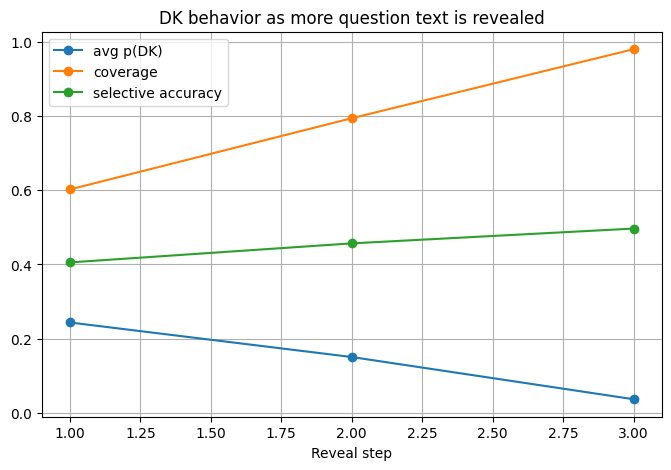

Fraction of samples where p(DK) decreases from step 1 to full step 3: 0.978


In [88]:

# =========================================================
# 10. Progressive reveal dataset and analysis
# =========================================================

class DKProgressiveRevealDataset(Dataset):
    def __init__(self, ds, split, tokenizer, config: Config):
        rows = list(ds[split])
        prompts, answers, subjects, step_indices, reveal_ratios, original_indices = [], [], [], [], [], []

        for original_idx, row in enumerate(rows):
            answer = int(row["answer"])
            parts, ratios = cutted_question(row["question"], config.m_steps)
            for step_idx, (part, ratio) in enumerate(zip(parts, ratios), start=1):
                prompts.append(build_prompt_dk(part, row["choices"]))
                answers.append(answer)
                subjects.append(row.get("subject", "unknown"))
                step_indices.append(step_idx)
                reveal_ratios.append(float(ratio))
                original_indices.append(original_idx)

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=config.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.answers = torch.tensor(answers, dtype=torch.long)
        self.subjects = subjects
        self.step_indices = torch.tensor(step_indices, dtype=torch.long)
        self.reveal_ratios = torch.tensor(reveal_ratios, dtype=torch.float32)
        self.original_indices = torch.tensor(original_indices, dtype=torch.long)

    def __len__(self):
        return len(self.answers)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "answer": self.answers[idx],
            "subject": self.subjects[idx],
            "step_idx": self.step_indices[idx],
            "reveal_ratio": self.reveal_ratios[idx],
            "original_idx": self.original_indices[idx],
        }


@torch.no_grad()
def collect_dk_progressive_outputs(model, loader, use_amp=True):
    out = collect_dk_outputs(model, loader, use_amp=use_amp)
    all_step_idx, all_reveal_ratio, all_original_idx = [], [], []
    for batch in loader:
        all_step_idx.append(batch["step_idx"].detach().cpu())
        all_reveal_ratio.append(batch["reveal_ratio"].detach().cpu())
        all_original_idx.append(batch["original_idx"].detach().cpu())
    out["step_idx"] = torch.cat(all_step_idx)
    out["reveal_ratio"] = torch.cat(all_reveal_ratio)
    out["original_idx"] = torch.cat(all_original_idx)
    return ensure_extra_scores(out)

progressive_test_ds = DKProgressiveRevealDataset(small_mmlu, "test", tokenizer, config)
progressive_test_loader = DataLoader(
    progressive_test_ds,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=torch.cuda.is_available(),
)

progressive_outputs = collect_dk_progressive_outputs(dk_model, progressive_test_loader)

# Metrics by reveal step using pure argmax DK.
prog_rows = []
for step in sorted(progressive_outputs["step_idx"].unique().tolist()):
    mask = progressive_outputs["step_idx"] == step
    sub = {k: (v[mask] if torch.is_tensor(v) and len(v) == len(mask) else v) for k, v in progressive_outputs.items()}
    m = apply_dk_argmax(sub)
    prog_rows.append({
        "step": int(step),
        "reveal_ratio_mean": float(progressive_outputs["reveal_ratio"][mask].float().mean().item()),
        "avg_p_dk": float(progressive_outputs["p_dk"][mask].float().mean().item()),
        "forced_accuracy": float((sub["preds"] == sub["labels"]).float().mean().item()),
        "coverage_argmax": m["coverage"],
        "selective_accuracy_argmax": m["selective_accuracy"],
        "dk_rate_argmax": m["dk_rate"],
    })

progressive_step_table = pd.DataFrame(prog_rows)
display(progressive_step_table)

plt.figure(figsize=(8, 5))
plt.plot(progressive_step_table["step"], progressive_step_table["avg_p_dk"], marker="o", label="avg p(DK)")
plt.plot(progressive_step_table["step"], progressive_step_table["coverage_argmax"], marker="o", label="coverage")
plt.plot(progressive_step_table["step"], progressive_step_table["selective_accuracy_argmax"], marker="o", label="selective accuracy")
plt.xlabel("Reveal step")
plt.title("DK behavior as more question text is revealed")
plt.legend()
plt.grid(True)
plt.show()

# How often does p(DK) decrease from first reveal to full question?
prog_df = pd.DataFrame({
    "original_idx": progressive_outputs["original_idx"].numpy(),
    "step": progressive_outputs["step_idx"].numpy(),
    "p_dk": progressive_outputs["p_dk"].numpy(),
})
pivot_pdk = prog_df.pivot_table(index="original_idx", columns="step", values="p_dk", aggfunc="first")
first_step = pivot_pdk.columns.min()
last_step = pivot_pdk.columns.max()
pdk_decrease_rate = float((pivot_pdk[last_step] < pivot_pdk[first_step]).mean())
print(f"Fraction of samples where p(DK) decreases from step {first_step} to full step {last_step}: {pdk_decrease_rate:.3f}")



## 11. Early-answering experiment

The model sees progressively more of the question. It answers at the first step where it does **not** choose DK. If it always chooses DK, it abstains.


,method,n_questions,coverage,selective_accuracy,effective_accuracy,avg_answer_step_among_answered
0,DK progressive early answer argmax,14042,0.984475,0.417101,0.410625,1.529152


,count
answer_step,
1.0,8457
2.0,3419
3.0,1948
NaN,218


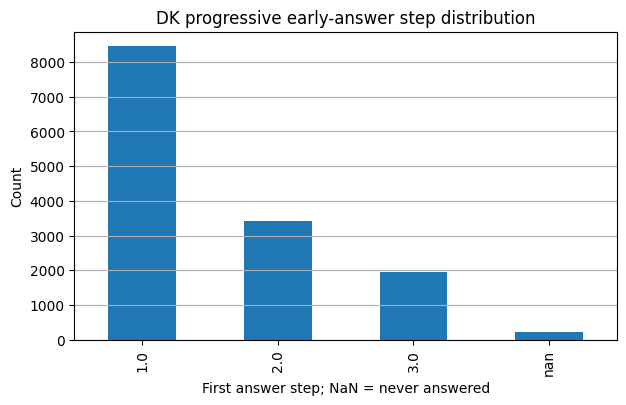

In [89]:

# =========================================================
# 11. Early answering experiment
# =========================================================

prog = pd.DataFrame({
    "original_idx": progressive_outputs["original_idx"].numpy(),
    "step": progressive_outputs["step_idx"].numpy(),
    "label": progressive_outputs["labels"].numpy(),
    "pred": progressive_outputs["preds"].numpy(),
    "p_dk": progressive_outputs["p_dk"].numpy(),
    "should_answer_argmax": progressive_outputs["should_answer_argmax"].numpy().astype(bool),
})

rows = []
for original_idx, g in prog.sort_values(["original_idx", "step"]).groupby("original_idx"):
    answer_rows = g[g["should_answer_argmax"]]
    if len(answer_rows) == 0:
        first = g.iloc[-1]
        rows.append({
            "original_idx": original_idx,
            "answered": False,
            "answer_step": np.nan,
            "label": int(first["label"]),
            "pred": 4,
            "correct": False,
        })
    else:
        first = answer_rows.iloc[0]
        rows.append({
            "original_idx": original_idx,
            "answered": True,
            "answer_step": int(first["step"]),
            "label": int(first["label"]),
            "pred": int(first["pred"]),
            "correct": bool(first["pred"] == first["label"]),
        })

early_answer_df = pd.DataFrame(rows)
early_answer_summary = pd.DataFrame([{
    "method": "DK progressive early answer argmax",
    "n_questions": len(early_answer_df),
    "coverage": early_answer_df["answered"].mean(),
    "selective_accuracy": early_answer_df.loc[early_answer_df["answered"], "correct"].mean(),
    "effective_accuracy": (early_answer_df["answered"] & early_answer_df["correct"]).mean(),
    "avg_answer_step_among_answered": early_answer_df.loc[early_answer_df["answered"], "answer_step"].mean(),
}])
display(early_answer_summary)

display(early_answer_df["answer_step"].value_counts(dropna=False).sort_index().rename("count").to_frame())

plt.figure(figsize=(7, 4))
early_answer_df["answer_step"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.xlabel("First answer step; NaN = never answered")
plt.ylabel("Count")
plt.title("DK progressive early-answer step distribution")
plt.grid(axis="y")
plt.show()



# 13. Cross-dataset evaluation: SciQ, GSM8K, and MMLU-Pro

This section compares the **baseline model** and the **DK / Smart Chimera model** on additional datasets.

Important: all datasets are converted into the same **4-choice A/B/C/D format** so that they match the models trained in this notebook.

- **SciQ** is naturally multiple-choice, but the choices are shuffled deterministically.
- **GSM8K** is originally open-ended math. Here it is converted into an artificial 4-choice numeric task.
- **MMLU-Pro** usually has more than 4 options. Here we keep the correct answer and sample 3 distractors deterministically.

For each dataset, the code uses a **validation split to choose thresholds** for target coverage levels, then evaluates on the test split.


Cross-dataset evaluation: SciQ
Validation rows: 1000 | Test rows: 1000


collect baseline:   0%|          | 0/125 [00:00<?, ?it/s]

collect baseline:   0%|          | 0/125 [00:00<?, ?it/s]

collect DK:   0%|          | 0/125 [00:00<?, ?it/s]

collect DK:   0%|          | 0/125 [00:00<?, ?it/s]


Sanity check: at target coverage=1.0, selective accuracy should match forced accuracy.
Baseline: forced accuracy=0.8240, selective accuracy at target coverage=1.0 is 0.8240
DK p(DK) sweep: forced accuracy=0.8020, selective accuracy at target coverage=1.0 is 0.8028

Summary:


,dataset,method,score_name,forced_accuracy,auroc,ece,test_coverage_at_target_0.7,test_selective_accuracy_at_target_0.7,test_dk_rate_at_target_0.7
0,SciQ,Baseline: max confidence,baseline_conf,0.824,0.861333,0.041374,0.699,0.941345,0.301
1,SciQ,DK: 1 - p(DK),dk_one_minus_pdk,0.802,0.663883,0.180785,0.703,0.834993,0.297
2,SciQ,DK: answer confidence,dk_answer_conf,0.802,0.828119,0.049556,0.701,0.917261,0.299
3,SciQ,DK: answer_conf * (1-pDK),dk_product,0.802,0.820090,0.051734,0.705,0.916312,0.295
4,SciQ,DK: answer_conf - pDK,dk_margin,0.802,0.817514,0.053372,0.703,0.917496,0.297
5,SciQ,DK: argmax-only,argmax(A/B/C/D/E),0.802,NaN,NaN,0.991,0.804238,0.009



Coverage table:


,dataset,method,score_name,target_coverage,threshold_from_val,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_effective_accuracy,test_dk_rate
0,SciQ,Baseline: max confidence,baseline_conf,1.0,0.274870,1.0,0.820000,1.000,0.824000,0.824,0.000
1,SciQ,Baseline: max confidence,baseline_conf,0.9,0.464962,0.9,0.860000,0.896,0.868304,0.778,0.104
2,SciQ,Baseline: max confidence,baseline_conf,0.8,0.570816,0.8,0.902500,0.798,0.901003,0.719,0.202
3,SciQ,Baseline: max confidence,baseline_conf,0.7,0.696261,0.7,0.935714,0.699,0.941345,0.658,0.301
4,SciQ,Baseline: max confidence,baseline_conf,0.6,0.803857,0.6,0.953333,0.590,0.967797,0.571,0.410
5,SciQ,Baseline: max confidence,baseline_conf,0.5,0.877835,0.5,0.972000,0.519,0.976879,0.507,0.481
6,SciQ,Baseline: max confidence,baseline_conf,0.4,0.933509,0.4,0.980000,0.411,0.990268,0.407,0.589
7,SciQ,Baseline: max confidence,baseline_conf,0.3,0.960101,0.3,0.993333,0.324,0.993827,0.322,0.676
8,SciQ,Baseline: max confidence,baseline_conf,0.2,0.979536,0.2,1.000000,0.208,1.000000,0.208,0.792
9,SciQ,Baseline: max confidence,baseline_conf,0.1,0.990031,0.1,1.000000,0.094,1.000000,0.094,0.906


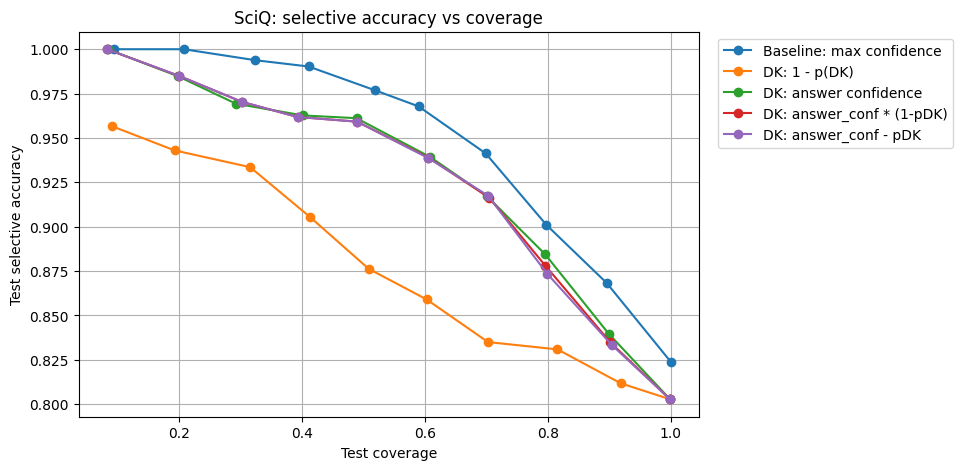

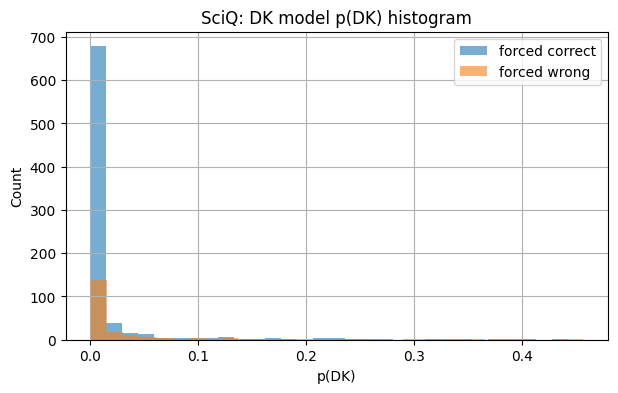

Cross-dataset evaluation: GSM8K
Validation rows: 1000 | Test rows: 1000


collect baseline:   0%|          | 0/125 [00:00<?, ?it/s]

collect baseline:   0%|          | 0/125 [00:00<?, ?it/s]

collect DK:   0%|          | 0/125 [00:00<?, ?it/s]

collect DK:   0%|          | 0/125 [00:00<?, ?it/s]


Sanity check: at target coverage=1.0, selective accuracy should match forced accuracy.
Baseline: forced accuracy=0.1860, selective accuracy at target coverage=1.0 is 0.1862
DK p(DK) sweep: forced accuracy=0.2340, selective accuracy at target coverage=1.0 is 0.2340

Summary:


,dataset,method,score_name,forced_accuracy,auroc,ece,test_coverage_at_target_0.7,test_selective_accuracy_at_target_0.7,test_dk_rate_at_target_0.7
0,GSM8K,Baseline: max confidence,baseline_conf,0.186,0.350156,0.168072,0.740,0.155405,0.260
1,GSM8K,DK: 1 - p(DK),dk_one_minus_pdk,0.234,0.446509,0.720028,0.647,0.210201,0.353
2,GSM8K,DK: answer confidence,dk_answer_conf,0.234,0.405704,0.161485,0.667,0.202399,0.333
3,GSM8K,DK: answer_conf * (1-pDK),dk_product,0.234,0.406468,0.153666,0.670,0.207463,0.330
4,GSM8K,DK: answer_conf - pDK,dk_margin,0.234,0.408627,0.154632,0.666,0.210210,0.334
5,GSM8K,DK: argmax-only,argmax(A/B/C/D/E),0.234,NaN,NaN,0.995,0.234171,0.005



Coverage table:


,dataset,method,score_name,target_coverage,threshold_from_val,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_effective_accuracy,test_dk_rate
0,GSM8K,Baseline: max confidence,baseline_conf,1.0,0.256334,1.0,0.183000,0.999,0.186186,0.186,0.001
1,GSM8K,Baseline: max confidence,baseline_conf,0.9,0.293094,0.9,0.172222,0.919,0.171926,0.158,0.081
2,GSM8K,Baseline: max confidence,baseline_conf,0.8,0.307199,0.8,0.155000,0.812,0.162562,0.132,0.188
3,GSM8K,Baseline: max confidence,baseline_conf,0.7,0.317477,0.7,0.152857,0.740,0.155405,0.115,0.260
4,GSM8K,Baseline: max confidence,baseline_conf,0.6,0.327075,0.6,0.143333,0.659,0.147193,0.097,0.341
5,GSM8K,Baseline: max confidence,baseline_conf,0.5,0.340722,0.5,0.122000,0.515,0.124272,0.064,0.485
6,GSM8K,Baseline: max confidence,baseline_conf,0.4,0.354333,0.4,0.112500,0.405,0.093827,0.038,0.595
7,GSM8K,Baseline: max confidence,baseline_conf,0.3,0.368271,0.3,0.103333,0.307,0.078176,0.024,0.693
8,GSM8K,Baseline: max confidence,baseline_conf,0.2,0.387344,0.2,0.090000,0.214,0.074766,0.016,0.786
9,GSM8K,Baseline: max confidence,baseline_conf,0.1,0.424816,0.1,0.090000,0.096,0.020833,0.002,0.904


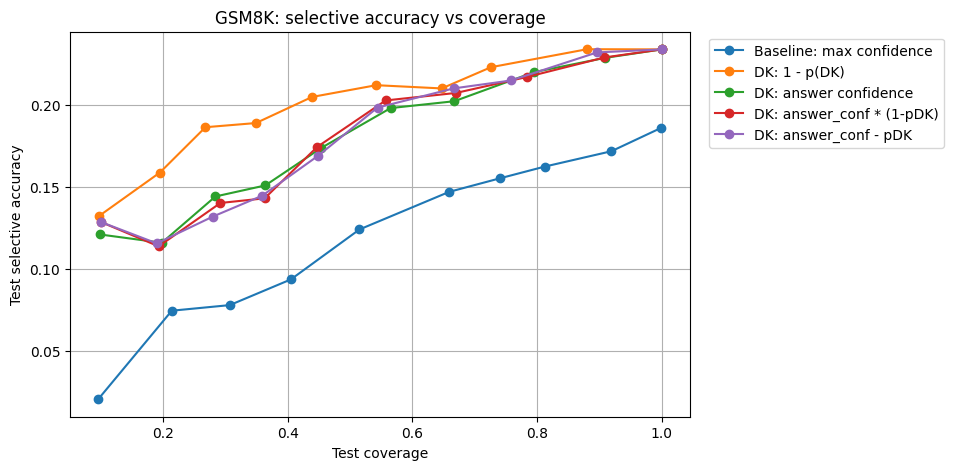

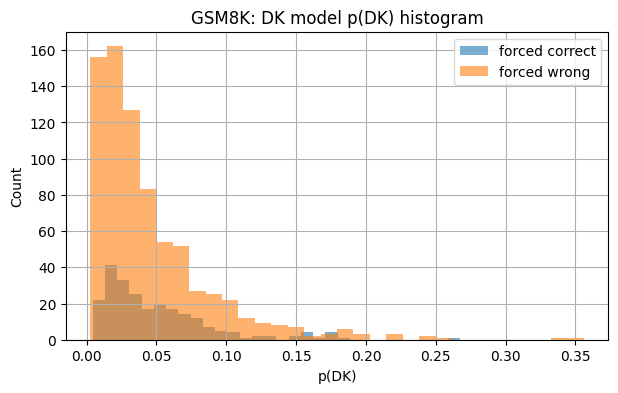

MMLU-Pro validation: built 70 rows, skipped 0
MMLU-Pro test: built 1000 rows, skipped 0
Cross-dataset evaluation: MMLU-Pro
Validation rows: 70 | Test rows: 1000


collect baseline:   0%|          | 0/9 [00:00<?, ?it/s]

collect baseline:   0%|          | 0/125 [00:00<?, ?it/s]

collect DK:   0%|          | 0/9 [00:00<?, ?it/s]

collect DK:   0%|          | 0/125 [00:00<?, ?it/s]


Sanity check: at target coverage=1.0, selective accuracy should match forced accuracy.
Baseline: forced accuracy=0.3950, selective accuracy at target coverage=1.0 is 0.3983
DK p(DK) sweep: forced accuracy=0.4030, selective accuracy at target coverage=1.0 is 0.4034

Summary:


,dataset,method,score_name,forced_accuracy,auroc,ece,test_coverage_at_target_0.7,test_selective_accuracy_at_target_0.7,test_dk_rate_at_target_0.7
0,MMLU-Pro,Baseline: max confidence,baseline_conf,0.395,0.586367,0.051959,0.442,0.481900,0.558
1,MMLU-Pro,DK: 1 - p(DK),dk_one_minus_pdk,0.403,0.533555,0.547926,0.710,0.412676,0.290
2,MMLU-Pro,DK: answer confidence,dk_answer_conf,0.403,0.595912,0.071138,0.569,0.456942,0.431
3,MMLU-Pro,DK: answer_conf * (1-pDK),dk_product,0.403,0.591219,0.086225,0.595,0.455462,0.405
4,MMLU-Pro,DK: answer_conf - pDK,dk_margin,0.403,0.585055,0.099511,0.626,0.444089,0.374
5,MMLU-Pro,DK: argmax-only,argmax(A/B/C/D/E),0.403,NaN,NaN,0.975,0.409231,0.025



Coverage table:


,dataset,method,score_name,target_coverage,threshold_from_val,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_effective_accuracy,test_dk_rate
0,MMLU-Pro,Baseline: max confidence,baseline_conf,1.0,0.285634,1.0,0.414286,0.964,0.398340,0.384,0.036
1,MMLU-Pro,Baseline: max confidence,baseline_conf,0.9,0.322851,0.9,0.460317,0.820,0.415854,0.341,0.180
2,MMLU-Pro,Baseline: max confidence,baseline_conf,0.8,0.343115,0.8,0.446429,0.698,0.429799,0.300,0.302
3,MMLU-Pro,Baseline: max confidence,baseline_conf,0.7,0.397135,0.7,0.489796,0.442,0.481900,0.213,0.558
4,MMLU-Pro,Baseline: max confidence,baseline_conf,0.6,0.477623,0.6,0.523810,0.236,0.470339,0.111,0.764
5,MMLU-Pro,Baseline: max confidence,baseline_conf,0.5,0.546234,0.5,0.628571,0.145,0.475862,0.069,0.855
6,MMLU-Pro,Baseline: max confidence,baseline_conf,0.4,0.588996,0.4,0.678571,0.115,0.460870,0.053,0.885
7,MMLU-Pro,Baseline: max confidence,baseline_conf,0.3,0.676552,0.3,0.714286,0.070,0.500000,0.035,0.930
8,MMLU-Pro,Baseline: max confidence,baseline_conf,0.2,0.759386,0.2,0.785714,0.053,0.547170,0.029,0.947
9,MMLU-Pro,Baseline: max confidence,baseline_conf,0.1,0.852172,0.1,0.857143,0.030,0.600000,0.018,0.970


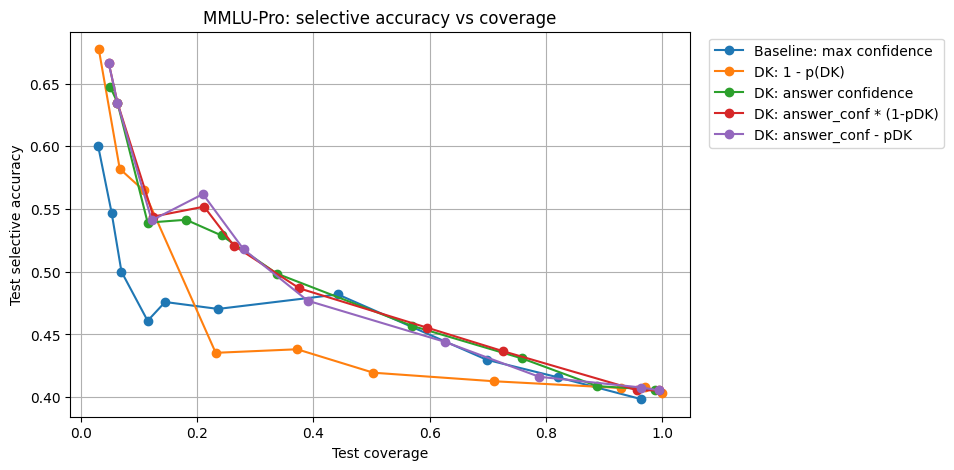

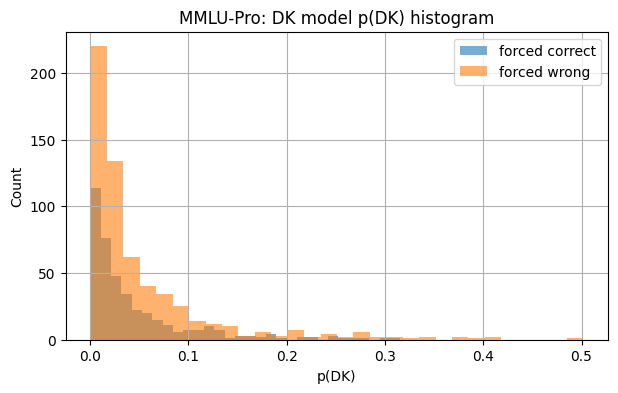


Combined cross-dataset summary:


,dataset,method,score_name,forced_accuracy,auroc,ece,test_coverage_at_target_0.7,test_selective_accuracy_at_target_0.7,test_dk_rate_at_target_0.7
0,SciQ,Baseline: max confidence,baseline_conf,0.824,0.861333,0.041374,0.699,0.941345,0.301
1,SciQ,DK: 1 - p(DK),dk_one_minus_pdk,0.802,0.663883,0.180785,0.703,0.834993,0.297
2,SciQ,DK: answer confidence,dk_answer_conf,0.802,0.828119,0.049556,0.701,0.917261,0.299
3,SciQ,DK: answer_conf * (1-pDK),dk_product,0.802,0.820090,0.051734,0.705,0.916312,0.295
4,SciQ,DK: answer_conf - pDK,dk_margin,0.802,0.817514,0.053372,0.703,0.917496,0.297
5,SciQ,DK: argmax-only,argmax(A/B/C/D/E),0.802,NaN,NaN,0.991,0.804238,0.009
6,GSM8K,Baseline: max confidence,baseline_conf,0.186,0.350156,0.168072,0.740,0.155405,0.260
7,GSM8K,DK: 1 - p(DK),dk_one_minus_pdk,0.234,0.446509,0.720028,0.647,0.210201,0.353
8,GSM8K,DK: answer confidence,dk_answer_conf,0.234,0.405704,0.161485,0.667,0.202399,0.333
9,GSM8K,DK: answer_conf * (1-pDK),dk_product,0.234,0.406468,0.153666,0.670,0.207463,0.330



Combined cross-dataset curves:


,dataset,method,score_name,target_coverage,threshold_from_val,val_coverage,val_selective_accuracy,test_coverage,test_selective_accuracy,test_effective_accuracy,test_dk_rate
0,SciQ,Baseline: max confidence,baseline_conf,1.0,0.274870,1.0,0.820000,1.000,0.824000,0.824,0.000
1,SciQ,Baseline: max confidence,baseline_conf,0.9,0.464962,0.9,0.860000,0.896,0.868304,0.778,0.104
2,SciQ,Baseline: max confidence,baseline_conf,0.8,0.570816,0.8,0.902500,0.798,0.901003,0.719,0.202
3,SciQ,Baseline: max confidence,baseline_conf,0.7,0.696261,0.7,0.935714,0.699,0.941345,0.658,0.301
4,SciQ,Baseline: max confidence,baseline_conf,0.6,0.803857,0.6,0.953333,0.590,0.967797,0.571,0.410
...,...,...,...,...,...,...,...,...,...,...,...
145,MMLU-Pro,DK: answer_conf - pDK,dk_margin,0.5,0.491834,0.5,0.600000,0.280,0.517857,0.145,0.720
146,MMLU-Pro,DK: answer_conf - pDK,dk_margin,0.4,0.554301,0.4,0.642857,0.210,0.561905,0.118,0.790
147,MMLU-Pro,DK: answer_conf - pDK,dk_margin,0.3,0.656130,0.3,0.714286,0.122,0.540984,0.066,0.878
148,MMLU-Pro,DK: answer_conf - pDK,dk_margin,0.2,0.793886,0.2,0.785714,0.063,0.634921,0.040,0.937


Saved:
- cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv
- cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv


In [90]:

# =========================================================
# 13. Cross-dataset evaluation: SciQ, GSM8K, MMLU-Pro
# =========================================================

import hashlib
from datasets import load_dataset

CROSS_DATASET_TARGET_COVERAGES = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
CROSS_DATASET_MAX_VAL = 1000
CROSS_DATASET_MAX_TEST = 1000
CROSS_DATASET_BATCH_SIZE = getattr(config, "eval_batch_size", 8)


def stable_seed(text):
    """Stable deterministic seed. Do not use Python hash(), because it changes between sessions."""
    text = str(text)
    return int(hashlib.md5(text.encode("utf-8")).hexdigest()[:8], 16)


def deterministic_shuffle_choices(question, choices, correct_idx):
    """Shuffle choices while preserving the correct label."""
    rng = np.random.default_rng(stable_seed(question))
    perm = rng.permutation(len(choices))
    shuffled = [choices[i] for i in perm]
    new_label = int(np.where(perm == int(correct_idx))[0][0])
    return shuffled, new_label


def normalize_numeric_string(x):
    s = str(x).strip().replace(",", "")
    try:
        f = float(s)
        if abs(f - round(f)) < 1e-8:
            return str(int(round(f)))
        return str(round(f, 4)).rstrip("0").rstrip(".")
    except Exception:
        return s


class CrossDatasetABCDDataset(Dataset):
    """Generic row dataset for baseline A/B/C/D prompts."""
    def __init__(self, rows, tokenizer, max_length=512):
        self.rows = rows
        prompts, answers, subjects = [], [], []

        for row in rows:
            prompts.append(build_prompt_baseline(row["question"], row["choices"]))
            answers.append(int(row["answer"]))
            subjects.append(row.get("subject", "unknown"))

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )

        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.answers = torch.tensor(answers, dtype=torch.long)
        self.subjects = subjects

    def __len__(self):
        return len(self.answers)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "answer": self.answers[idx],
            "subject": self.subjects[idx],
        }


class CrossDatasetDKDataset(Dataset):
    """Generic row dataset for DK A/B/C/D/E prompts."""
    def __init__(self, rows, tokenizer, max_length=512):
        self.rows = rows
        prompts, answers, subjects = [], [], []

        for row in rows:
            prompts.append(build_prompt_dk(row["question"], row["choices"]))
            answers.append(int(row["answer"]))
            subjects.append(row.get("subject", "unknown"))

        enc = tokenizer(
            prompts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )

        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.answers = torch.tensor(answers, dtype=torch.long)
        self.subjects = subjects

    def __len__(self):
        return len(self.answers)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "answer": self.answers[idx],
            "subject": self.subjects[idx],
        }


def make_cross_loaders(rows, model_kind):
    if model_kind == "baseline":
        ds = CrossDatasetABCDDataset(rows, tokenizer, max_length=config.max_length)
    elif model_kind == "dk":
        ds = CrossDatasetDKDataset(rows, tokenizer, max_length=config.max_length)
    else:
        raise ValueError(model_kind)
    return DataLoader(ds, batch_size=CROSS_DATASET_BATCH_SIZE, shuffle=False, num_workers=0)


# ---------------------------------------------------------
# Dataset builders
# ---------------------------------------------------------

def build_sciq_rows(split, max_items=None):
    ds = load_dataset("sciq", split=split)
    if max_items is not None:
        ds = ds.select(range(min(max_items, len(ds))))

    rows = []
    for ex in ds:
        choices = [
            str(ex["correct_answer"]),
            str(ex["distractor1"]),
            str(ex["distractor2"]),
            str(ex["distractor3"]),
        ]
        # correct is initially index 0
        shuffled, label = deterministic_shuffle_choices(ex["question"], choices, 0)
        rows.append({
            "question": str(ex["question"]),
            "choices": shuffled[:4],
            "answer": label,
            "subject": "SciQ",
        })
    return rows


def extract_gsm8k_final_answer(answer_text):
    text = str(answer_text)
    if "####" in text:
        ans = text.split("####")[-1].strip()
    else:
        ans = text.strip().split()[-1]
    return normalize_numeric_string(ans)


def make_gsm8k_numeric_choices(correct_str, question):
    correct_str = normalize_numeric_string(correct_str)
    try:
        correct = float(correct_str)
    except Exception:
        base = [correct_str, "0", "1", "2", "3", "4"]
        # remove duplicates while preserving order
        seen, choices = set(), []
        for x in base:
            if x not in seen:
                seen.add(x)
                choices.append(x)
        return choices[:4], 0

    candidates = [
        correct + 1,
        correct - 1,
        correct + 2,
        correct - 2,
        correct * 2,
        correct / 2 if correct != 0 else 1,
        correct + 10,
        correct - 10,
        correct * 10,
        correct / 10 if correct != 0 else 10,
    ]

    choices = [correct_str]
    for x in candidates:
        s = normalize_numeric_string(x)
        if s not in choices:
            choices.append(s)
        if len(choices) == 4:
            break

    # deterministic fallback
    k = 0
    while len(choices) < 4:
        s = normalize_numeric_string(correct + 100 + k)
        if s not in choices:
            choices.append(s)
        k += 1

    return choices[:4], 0


def build_gsm8k_rows(split, max_items=None):
    ds = load_dataset("gsm8k", "main", split=split)
    if max_items is not None:
        ds = ds.select(range(min(max_items, len(ds))))

    rows = []
    for ex in ds:
        correct = extract_gsm8k_final_answer(ex["answer"])
        choices, correct_idx = make_gsm8k_numeric_choices(correct, ex["question"])
        shuffled, label = deterministic_shuffle_choices(ex["question"], choices, correct_idx)
        rows.append({
            "question": str(ex["question"]),
            "choices": shuffled[:4],
            "answer": label,
            "subject": "GSM8K",
        })
    return rows


def get_mmlu_pro_choices_and_answer(ex):
    # MMLU-Pro commonly uses fields: question, options, answer, answer_index/category.
    choices = ex.get("options", None)
    if choices is None:
        choices = ex.get("choices", None)
    if choices is None:
        raise KeyError("Could not find options/choices in MMLU-Pro row.")
    choices = [str(x) for x in list(choices)]

    if "answer_index" in ex and ex["answer_index"] is not None:
        correct_idx = int(ex["answer_index"])
    elif "label" in ex and isinstance(ex["label"], (int, np.integer)):
        correct_idx = int(ex["label"])
    elif "answer" in ex:
        ans = ex["answer"]
        if isinstance(ans, (int, np.integer)):
            correct_idx = int(ans)
        else:
            ans_str = str(ans).strip()
            letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
            if len(ans_str) == 1 and ans_str.upper() in letters:
                correct_idx = letters.index(ans_str.upper())
            elif ans_str in choices:
                correct_idx = choices.index(ans_str)
            else:
                # sometimes answer is the text but differs by whitespace
                normalized = [c.strip() for c in choices]
                correct_idx = normalized.index(ans_str.strip())
    else:
        raise KeyError("Could not infer correct answer for MMLU-Pro row.")

    if not (0 <= correct_idx < len(choices)):
        raise ValueError(f"Invalid correct_idx={correct_idx} for {len(choices)} choices")

    return choices, correct_idx


def reduce_to_4_choices_keep_correct(question, choices, correct_idx):
    """MMLU-Pro may have more than 4 options. Keep correct + 3 deterministic distractors."""
    correct_choice = choices[int(correct_idx)]
    distractors = [c for i, c in enumerate(choices) if i != int(correct_idx) and c != correct_choice]
    rng = np.random.default_rng(stable_seed(question))
    rng.shuffle(distractors)
    four = [correct_choice] + distractors[:3]

    # fallback if duplicates reduce choices
    while len(four) < 4:
        candidate = f"None of the above {len(four)}"
        if candidate not in four:
            four.append(candidate)

    shuffled, label = deterministic_shuffle_choices(question, four, 0)
    return shuffled[:4], label


def build_mmlu_pro_rows(split, max_items=None):
    # Dataset name may require internet access in Colab.
    ds = load_dataset("TIGER-Lab/MMLU-Pro", split=split)
    if max_items is not None:
        ds = ds.select(range(min(max_items, len(ds))))

    rows = []
    skipped = 0
    for ex in ds:
        try:
            question = str(ex["question"])
            choices, correct_idx = get_mmlu_pro_choices_and_answer(ex)
            choices4, label = reduce_to_4_choices_keep_correct(question, choices, correct_idx)
            rows.append({
                "question": question,
                "choices": choices4,
                "answer": label,
                "subject": str(ex.get("category", ex.get("subject", "MMLU-Pro"))),
            })
        except Exception as e:
            skipped += 1
            if skipped <= 3:
                print("Skipped MMLU-Pro row due to:", repr(e))
    print(f"MMLU-Pro {split}: built {len(rows)} rows, skipped {skipped}")
    return rows


# ---------------------------------------------------------
# Generic score-threshold evaluation helpers
# ---------------------------------------------------------

def outputs_with_score(outputs, score_name):
    out = dict(outputs)
    if score_name == "baseline_conf":
        out["score"] = outputs["conf"]
    elif score_name == "dk_answer_conf":
        out["score"] = outputs["conf"]
    elif score_name == "dk_one_minus_pdk":
        out["score"] = 1.0 - outputs["p_dk"]
    elif score_name == "dk_product":
        out["score"] = outputs["conf"] * (1.0 - outputs["p_dk"])
    elif score_name == "dk_margin":
        out["score"] = outputs["conf"] - outputs["p_dk"]
    else:
        raise ValueError(f"Unknown score_name: {score_name}")
    return out


def apply_score_threshold(outputs, tau):
    labels = outputs["labels"]
    preds = outputs["preds"]
    score = outputs["score"]
    should_answer = score >= tau
    final_preds = preds.clone()
    final_preds[~should_answer] = 4
    return compute_operating_metrics(labels, preds, should_answer, final_preds, threshold=tau)


def build_score_coverage_table(val_outputs, test_outputs, method_name, score_name, target_coverages=CROSS_DATASET_TARGET_COVERAGES):
    val_s = outputs_with_score(val_outputs, score_name)
    test_s = outputs_with_score(test_outputs, score_name)
    rows = []
    for target_cov in target_coverages:
        tau = threshold_for_target_coverage(val_s["score"], target_cov)
        val_m = apply_score_threshold(val_s, tau)
        test_m = apply_score_threshold(test_s, tau)
        rows.append({
            "method": method_name,
            "score_name": score_name,
            "target_coverage": target_cov,
            "threshold_from_val": tau,
            "val_coverage": val_m["coverage"],
            "val_selective_accuracy": val_m["selective_accuracy"],
            "test_coverage": test_m["coverage"],
            "test_selective_accuracy": test_m["selective_accuracy"],
            "test_effective_accuracy": test_m["effective_accuracy"],
            "test_dk_rate": test_m["dk_rate"],
        })
    return pd.DataFrame(rows)


def compute_score_auroc_ece(outputs, score_name):
    out = outputs_with_score(outputs, score_name)
    out["conf_for_metric"] = out["score"]
    return {
        "auroc": compute_auroc(out, score_key="conf_for_metric"),
        "ece": compute_ece(out, score_key="conf_for_metric", n_bins=15),
    }


def check_coverage_one_equals_forced(curve_df, forced_acc, method_name):
    row = curve_df.loc[curve_df["target_coverage"] == 1.0]
    if len(row) == 0:
        return
    acc_at_one = float(row["test_selective_accuracy"].iloc[0])
    print(f"{method_name}: forced accuracy={forced_acc:.4f}, selective accuracy at target coverage=1.0 is {acc_at_one:.4f}")


def plot_cross_dataset_curves(dataset_name, curve_df):
    plt.figure(figsize=(8, 5))
    for method, group in curve_df.groupby("method"):
        group = group.sort_values("test_coverage")
        plt.plot(group["test_coverage"], group["test_selective_accuracy"], marker="o", label=method)
    plt.xlabel("Test coverage")
    plt.ylabel("Test selective accuracy")
    plt.title(f"{dataset_name}: selective accuracy vs coverage")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()


def plot_cross_dataset_pdk(dataset_name, dk_outputs):
    labels = dk_outputs["labels"].numpy()
    preds = dk_outputs["preds"].numpy()
    pdk = dk_outputs["p_dk"].numpy()
    correct = preds == labels

    plt.figure(figsize=(7, 4))
    plt.hist(pdk[correct], bins=30, alpha=0.6, label="forced correct")
    plt.hist(pdk[~correct], bins=30, alpha=0.6, label="forced wrong")
    plt.xlabel("p(DK)")
    plt.ylabel("Count")
    plt.title(f"{dataset_name}: DK model p(DK) histogram")
    plt.grid(True)
    plt.legend()
    plt.show()


def run_one_cross_dataset_eval(dataset_name, val_rows, test_rows):
    print("=" * 90)
    print(f"Cross-dataset evaluation: {dataset_name}")
    print("=" * 90)
    print(f"Validation rows: {len(val_rows)} | Test rows: {len(test_rows)}")

    baseline_val_loader = make_cross_loaders(val_rows, model_kind="baseline")
    baseline_test_loader = make_cross_loaders(test_rows, model_kind="baseline")
    dk_val_loader = make_cross_loaders(val_rows, model_kind="dk")
    dk_test_loader = make_cross_loaders(test_rows, model_kind="dk")

    print("Collecting baseline validation outputs...")
    b_val = collect_baseline_outputs(baseline_model, baseline_val_loader)
    print("Collecting baseline test outputs...")
    b_test = collect_baseline_outputs(baseline_model, baseline_test_loader)

    print("Collecting DK validation outputs...")
    d_val = collect_dk_outputs(dk_model, dk_val_loader)
    print("Collecting DK test outputs...")
    d_test = collect_dk_outputs(dk_model, dk_test_loader)

    # Main curves. Baseline uses max confidence. DK is evaluated with p(DK) and useful combined scores.
    baseline_curve = build_score_coverage_table(
        b_val, b_test,
        method_name="Baseline: max confidence",
        score_name="baseline_conf",
    )
    dk_pdk_curve = build_score_coverage_table(
        d_val, d_test,
        method_name="DK: 1 - p(DK)",
        score_name="dk_one_minus_pdk",
    )
    dk_answer_curve = build_score_coverage_table(
        d_val, d_test,
        method_name="DK: answer confidence",
        score_name="dk_answer_conf",
    )
    dk_product_curve = build_score_coverage_table(
        d_val, d_test,
        method_name="DK: answer_conf * (1-pDK)",
        score_name="dk_product",
    )
    dk_margin_curve = build_score_coverage_table(
        d_val, d_test,
        method_name="DK: answer_conf - pDK",
        score_name="dk_margin",
    )

    curve_df = pd.concat([
        baseline_curve,
        dk_pdk_curve,
        dk_answer_curve,
        dk_product_curve,
        dk_margin_curve,
    ], ignore_index=True)
    curve_df.insert(0, "dataset", dataset_name)

    # Argmax-only DK operating point.
    dk_argmax = apply_dk_argmax(d_test)

    # AUROC/ECE summary.
    summary_rows = []
    for method_name, outputs, score_name, forced_acc in [
        ("Baseline: max confidence", b_test, "baseline_conf", b_test["forced_accuracy"]),
        ("DK: 1 - p(DK)", d_test, "dk_one_minus_pdk", d_test["forced_accuracy"]),
        ("DK: answer confidence", d_test, "dk_answer_conf", d_test["forced_accuracy"]),
        ("DK: answer_conf * (1-pDK)", d_test, "dk_product", d_test["forced_accuracy"]),
        ("DK: answer_conf - pDK", d_test, "dk_margin", d_test["forced_accuracy"]),
    ]:
        m = compute_score_auroc_ece(outputs, score_name)
        row70 = curve_df[(curve_df["method"] == method_name) & (curve_df["target_coverage"] == 0.7)].iloc[0]
        summary_rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "score_name": score_name,
            "forced_accuracy": forced_acc,
            "auroc": m["auroc"],
            "ece": m["ece"],
            "test_coverage_at_target_0.7": row70["test_coverage"],
            "test_selective_accuracy_at_target_0.7": row70["test_selective_accuracy"],
            "test_dk_rate_at_target_0.7": row70["test_dk_rate"],
        })

    summary_rows.append({
        "dataset": dataset_name,
        "method": "DK: argmax-only",
        "score_name": "argmax(A/B/C/D/E)",
        "forced_accuracy": d_test["forced_accuracy"],
        "auroc": np.nan,
        "ece": np.nan,
        "test_coverage_at_target_0.7": dk_argmax["coverage"],
        "test_selective_accuracy_at_target_0.7": dk_argmax["selective_accuracy"],
        "test_dk_rate_at_target_0.7": dk_argmax["dk_rate"],
    })

    summary_df = pd.DataFrame(summary_rows)

    print("\nSanity check: at target coverage=1.0, selective accuracy should match forced accuracy.")
    check_coverage_one_equals_forced(baseline_curve, b_test["forced_accuracy"], "Baseline")
    check_coverage_one_equals_forced(dk_pdk_curve, d_test["forced_accuracy"], "DK p(DK) sweep")

    print("\nSummary:")
    display(summary_df)

    print("\nCoverage table:")
    display(curve_df)

    plot_cross_dataset_curves(dataset_name, curve_df)
    plot_cross_dataset_pdk(dataset_name, d_test)

    return {
        "dataset": dataset_name,
        "baseline_val_outputs": b_val,
        "baseline_test_outputs": b_test,
        "dk_val_outputs": d_val,
        "dk_test_outputs": d_test,
        "summary": summary_df,
        "curve": curve_df,
        "dk_argmax": dk_argmax,
    }


# ---------------------------------------------------------
# Build rows and run experiments
# ---------------------------------------------------------

cross_dataset_results = {}

# SciQ
sciq_val_rows = build_sciq_rows("validation", max_items=CROSS_DATASET_MAX_VAL)
sciq_test_rows = build_sciq_rows("test", max_items=CROSS_DATASET_MAX_TEST)
cross_dataset_results["SciQ"] = run_one_cross_dataset_eval("SciQ", sciq_val_rows, sciq_test_rows)

# GSM8K
# GSM8K has train/test only, so validation comes from train.
gsm8k_val_rows = build_gsm8k_rows("train", max_items=CROSS_DATASET_MAX_VAL)
gsm8k_test_rows = build_gsm8k_rows("test", max_items=CROSS_DATASET_MAX_TEST)
cross_dataset_results["GSM8K"] = run_one_cross_dataset_eval("GSM8K", gsm8k_val_rows, gsm8k_test_rows)

# MMLU-Pro
# If this cell fails because the dataset schema changed, print one row with:
# load_dataset("TIGER-Lab/MMLU-Pro", split="validation")[0]
try:
    mmlu_pro_val_rows = build_mmlu_pro_rows("validation", max_items=CROSS_DATASET_MAX_VAL)
    mmlu_pro_test_rows = build_mmlu_pro_rows("test", max_items=CROSS_DATASET_MAX_TEST)
    cross_dataset_results["MMLU-Pro"] = run_one_cross_dataset_eval("MMLU-Pro", mmlu_pro_val_rows, mmlu_pro_test_rows)
except Exception as e:
    print("MMLU-Pro evaluation failed. Error:", repr(e))
    print("Tip: inspect the dataset schema with:")
    print('load_dataset("TIGER-Lab/MMLU-Pro", split="validation")[0]')

# Combined summary across all successful datasets
cross_dataset_summary = pd.concat(
    [v["summary"] for v in cross_dataset_results.values()],
    ignore_index=True,
)
cross_dataset_curves = pd.concat(
    [v["curve"] for v in cross_dataset_results.values()],
    ignore_index=True,
)

print("\nCombined cross-dataset summary:")
display(cross_dataset_summary)

print("\nCombined cross-dataset curves:")
display(cross_dataset_curves)

cross_dataset_summary.to_csv("cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv", index=False)
cross_dataset_curves.to_csv("cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv", index=False)
print("Saved:")
print("- cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv")
print("- cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv")



## 12. Save extra experiment results


In [91]:

# =========================================================
# 12. Save all extra results
# =========================================================

score_comparison.to_csv("extra_score_comparison_auroc_ece.csv", index=False)
advanced_coverage_comparison.to_csv("extra_advanced_coverage_comparison.csv", index=False)
aurc_table.to_csv("extra_aurc_table.csv", index=False)
coverage_at_fixed_accuracy.to_csv("extra_coverage_at_fixed_accuracy.csv", index=False)
fixed_coverage_pivot.to_csv("extra_selective_accuracy_at_fixed_coverage.csv")
rejection_quality_table.to_csv("extra_rejection_quality_table.csv", index=False)
per_subject_table.to_csv("extra_per_subject_table.csv", index=False)
oracle_random_table.to_csv("extra_oracle_random_table.csv", index=False)
progressive_step_table.to_csv("extra_progressive_step_table.csv", index=False)
early_answer_summary.to_csv("extra_early_answer_summary.csv", index=False)
early_answer_df.to_csv("extra_early_answer_details.csv", index=False)

print("Saved extra experiment CSV files:")
print("- extra_score_comparison_auroc_ece.csv")
print("- extra_advanced_coverage_comparison.csv")
print("- extra_aurc_table.csv")
print("- extra_coverage_at_fixed_accuracy.csv")
print("- extra_selective_accuracy_at_fixed_coverage.csv")
print("- extra_rejection_quality_table.csv")
print("- extra_per_subject_table.csv")
print("- extra_oracle_random_table.csv")
print("- extra_progressive_step_table.csv")
print("- extra_early_answer_summary.csv")
print("- extra_early_answer_details.csv")


Saved extra experiment CSV files:
- extra_score_comparison_auroc_ece.csv
- extra_advanced_coverage_comparison.csv
- extra_aurc_table.csv
- extra_coverage_at_fixed_accuracy.csv
- extra_selective_accuracy_at_fixed_coverage.csv
- extra_rejection_quality_table.csv
- extra_per_subject_table.csv
- extra_oracle_random_table.csv
- extra_progressive_step_table.csv
- extra_early_answer_summary.csv
- extra_early_answer_details.csv


# Save results

In [92]:
comparison_summary.to_csv("comparison_summary_metrics.csv", index=False)
coverage_comparison.to_csv("comparison_coverage_table.csv", index=False)
baseline_calibration.to_csv("baseline_calibration_table.csv", index=False)
dk_calibration.to_csv("dk_calibration_table.csv", index=False)

print("Saved:")
print("- comparison_summary_metrics.csv")
print("- comparison_coverage_table.csv")
print("- baseline_calibration_table.csv")
print("- dk_calibration_table.csv")
# Cross-dataset outputs are created only if Section 13 was run.
if "cross_dataset_summary" in globals():
    cross_dataset_summary.to_csv("cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv", index=False)
    cross_dataset_curves.to_csv("cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv", index=False)
    print("- cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv")
    print("- cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv")


Saved:
- comparison_summary_metrics.csv
- comparison_coverage_table.csv
- baseline_calibration_table.csv
- dk_calibration_table.csv
- cross_dataset_summary_sciq_gsm8k_mmlu_pro.csv
- cross_dataset_curves_sciq_gsm8k_mmlu_pro.csv


In [93]:
import os
import shutil
import glob

# Create a directory in your Google Drive for the outcomes
drive_dir = "/content/drive/MyDrive/Colab_Outcomes"
os.makedirs(drive_dir, exist_ok=True)

# Copy all CSVs generated in the current working directory to Drive
csv_files = glob.glob("*.csv")
for file in csv_files:
    shutil.copy(file, os.path.join(drive_dir, file))

print(f"Copied {len(csv_files)} CSV files to {drive_dir}")

Copied 17 CSV files to /content/drive/MyDrive/Colab_Outcomes


Saved plot as PDF to: /content/drive/MyDrive/Colab_Outcomes/selective_accuracy_vs_coverage.pdf


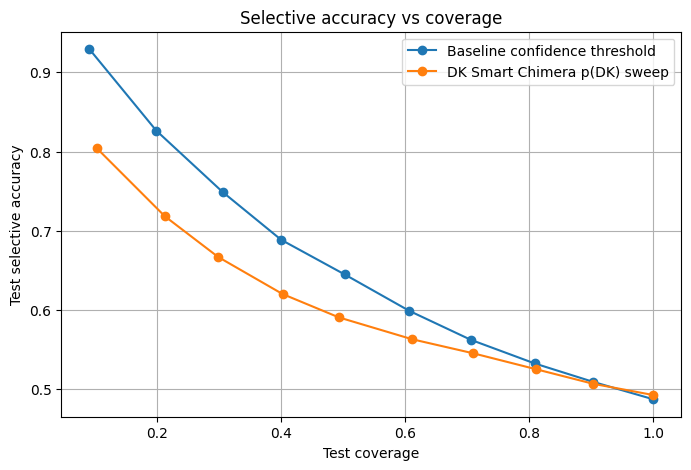

In [94]:
import matplotlib.pyplot as plt

# Example: Re-draw the "Selective accuracy vs coverage" plot and save it as a PDF
plt.figure(figsize=(8, 5))
for method_name, df in coverage_comparison.groupby("method"):
    plt.plot(df["test_coverage"], df["test_selective_accuracy"], marker="o", label=method_name)

plt.xlabel("Test coverage")
plt.ylabel("Test selective accuracy")
plt.title("Selective accuracy vs coverage")
plt.legend()
plt.grid(True)

# ---------------------------------------------------------
# Key step: Save as PDF *before* calling plt.show()
# bbox_inches="tight" ensures no labels are cut off in LaTeX
# ---------------------------------------------------------
pdf_path = os.path.join(drive_dir, "selective_accuracy_vs_coverage.pdf")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"Saved plot as PDF to: {pdf_path}")

plt.show()

## How to read the result

The most important comparison is not only forced accuracy. Look at:

- **Coverage:** how often the model answers.
- **Selective accuracy:** accuracy only among answered questions.
- **Effective accuracy:** correct answered questions divided by all test questions.
- **DK rate:** how often the model refuses.
- **AUROC:** how well confidence separates correct from wrong forced answers.

For the DK model, the main result is the **argmax-only** operating point. The coverage curve is still useful as an analysis tool, because it shows what happens when you sweep `p(DK)` like a threshold method.